# AI-Powered Customer Retention Intelligence Platform

# Notebook 6: Model Explainability & Business Intelligence

# Project Objective

The objective of this notebook is to interpret the predictions generated by the selected machine learning model and transform them into actionable business intelligence.

Rather than focusing solely on predictive accuracy, this notebook explains why customers are predicted to churn, identifies the most influential business factors, and prioritizes customers according to their estimated business value and churn risk.

The insights generated throughout this notebook will support explainable artificial intelligence (XAI), customer retention planning, executive reporting, and deployment within the AI-Powered Customer Retention Intelligence Platform.

# Business Context

Predictive models provide significant value only when business stakeholders understand how predictions are generated and how they can be translated into practical actions.

Explainable Artificial Intelligence (XAI) increases trust in predictive systems by identifying the customer characteristics that contribute most strongly to churn predictions.

By combining churn probabilities, customer value, and engineered business features, organizations can prioritize retention efforts, allocate resources efficiently, and improve customer lifetime value.

This notebook transforms machine learning outputs into practical business recommendations that support data-driven decision-making.

# Learning Objectives

Upon completion of this notebook, we will be able to:

- Generate churn probability predictions.
- Interpret prediction confidence.
- Analyze feature importance.
- Rank customers by churn risk.
- Segment customers by business value and risk.
- Generate customer retention recommendations.
- Build executive business dashboards.
- Prepare outputs for deployment.

# Expected Outputs

By the end of this notebook, the following deliverables will be completed:

- Customer churn probability predictions
- Customer risk ranking
- Customer priority segmentation
- Feature importance analysis
- Executive dashboards
- Retention recommendations
- Business intelligence reports
- Deployment-ready prediction dataset

# Notebook Structure

## Section 1 — Import Libraries

Import all required Python libraries.

---

## Section 2 — Load Production Model

Load the trained model and deployment artifacts.

---

## Section 3 — Generate Predictions

Predict customer churn probabilities.

---

## Section 4 — Customer Risk Ranking

Rank customers according to predicted churn probability.

---

## Section 5 — Business Segmentation

Segment customers using:

- Churn Probability
- Customer Value Score
- Customer Risk Score

---

## Section 6 — Feature Importance Analysis

Explain model predictions using feature importance.

---

## Section 7 — Executive Dashboard

Create executive business visualizations.

---

## Section 8 — Customer Retention Recommendations

Generate retention recommendations based on customer segments.

---

## Section 9 — Export Prediction Results

Export business-ready prediction reports.

---

## Executive Summary

# Section 1 — **Import Libraries**


This section imports all Python libraries required for model interpretation, prediction generation, business intelligence reporting, and visualization.

The libraries loaded in this notebook support the complete post-modeling workflow, including loading the trained production model, generating churn probability predictions, creating customer risk rankings, producing executive dashboards, and exporting business-ready reports.

These tools establish the environment necessary for transforming machine learning outputs into actionable business intelligence that supports customer retention strategies and executive decision-making.

## Objectives

This section performs the following tasks:

- Import data manipulation libraries.
- Import visualization libraries.
- Load model serialization tools.
- Configure notebook display settings.
- Prepare the environment for business intelligence analysis.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# File Management
import os
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Notebook Configuration
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

print("Business Intelligence libraries imported successfully.")

Business Intelligence libraries imported successfully.


In [2]:
# Dashboard Theme

PRIMARY = "#2563EB"      # Blue

SECONDARY = "#059669"    # Green

WARNING = "#F59E0B"      # Orange

DANGER = "#DC2626"       # Red

PURPLE = "#7C3AED"

BACKGROUND = "#F8FAFC"

print("Dashboard theme initialized.")

Dashboard theme initialized.


In [3]:
def style_chart(title, xlabel="", ylabel=""):

    plt.title(
        title,
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        xlabel,
        fontsize=12
    )

    plt.ylabel(
        ylabel,
        fontsize=12
    )

    plt.grid(
        alpha=0.3
    )

    sns.despine()

    plt.tight_layout()

print("Chart styling function ready.")

Chart styling function ready.


# Section 2 — **Load Production Model**


This section loads the trained production model and its supporting deployment artifacts created during **Notebook 5: Machine Learning Model Development**.

The deployment artifacts include:

- The selected production model
- The expected model feature names
- Model metadata
- The machine-learning-ready dataset
- The feature-engineered business dataset

Loading these files allows this notebook to generate customer churn probabilities, verify feature alignment, produce customer risk rankings, and create business intelligence reports without retraining the model.

The model input structure must exactly match the feature names and order used during training. Therefore, this section also validates the consistency of all production artifacts before predictions are generated.

## Objectives

This section performs the following tasks:

- Connect to the project directory.
- Load the selected production model.
- Load the expected predictor feature names.
- Load model metadata.
- Load the machine-learning-ready dataset.
- Load the business-readable feature-engineered dataset.
- Confirm that all production artifacts are available.
- Validate model and feature compatibility.

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
# Project Directory Configuration

PROJECT_PATH = "/content/drive/MyDrive/customer-churn-prediction"

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

MODELS_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)

REPORTS_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

EXPORTS_PATH = os.path.join(
    PROJECT_PATH,
    "exports"
)

FIGURES_PATH = os.path.join(
    PROJECT_PATH,
    "figures"
)

for folder in [
    PROCESSED_DATA_PATH,
    MODELS_PATH,
    REPORTS_PATH,
    EXPORTS_PATH,
    FIGURES_PATH
]:
    os.makedirs(folder, exist_ok=True)

print("Project directories verified successfully.")

Project directories verified successfully.


In [7]:
# Production Artifact Paths

MODEL_PATH = os.path.join(
    MODELS_PATH,
    "customer_churn_model.pkl"
)

FEATURE_NAMES_PATH = os.path.join(
    MODELS_PATH,
    "model_feature_names.pkl"
)

MODEL_METADATA_PATH = os.path.join(
    MODELS_PATH,
    "model_metadata.pkl"
)

ML_READY_DATA_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "customer_churn_ml_ready.csv"
)

FEATURE_ENGINEERED_DATA_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "customer_churn_feature_engineered.csv"
)

print("Production artifact paths configured successfully.")

Production artifact paths configured successfully.


In [9]:
# Production Artifact Availability Check

required_artifacts = {
    "Production Model": MODEL_PATH,
    "Feature Names": FEATURE_NAMES_PATH,
    "Model Metadata": MODEL_METADATA_PATH,
    "ML-Ready Dataset": ML_READY_DATA_PATH,
    "Feature-Engineered Dataset": FEATURE_ENGINEERED_DATA_PATH
}

missing_artifacts = []

print("=" * 60)
print("PRODUCTION ARTIFACT CHECK")
print("=" * 60)

for artifact_name, artifact_path in required_artifacts.items():

    if os.path.exists(artifact_path):

        print(f"✓ {artifact_name}")

    else:

        print(f"✗ {artifact_name}")
        missing_artifacts.append(artifact_name)

if missing_artifacts:
    print("\nMissing artifacts detected:")
    for artifact in missing_artifacts:
        print(f"- {artifact}")
else:
    print("\nAll required production artifacts are available.")

PRODUCTION ARTIFACT CHECK
✓ Production Model
✓ Feature Names
✓ Model Metadata
✓ ML-Ready Dataset
✓ Feature-Engineered Dataset

All required production artifacts are available.


In [12]:
# Load Production Model and Metadata

production_model = joblib.load(
    MODEL_PATH
)

model_feature_names = joblib.load(
    FEATURE_NAMES_PATH
)

model_metadata = joblib.load(
    MODEL_METADATA_PATH
)

print("Production model and supporting metadata loaded successfully.")

Production model and supporting metadata loaded successfully.


In [14]:
# Load Production Datasets

df_ml = pd.read_csv(
    ML_READY_DATA_PATH
)

df_business = pd.read_csv(
    FEATURE_ENGINEERED_DATA_PATH
)

print("Production datasets loaded successfully.")

print(f"\nML-ready dataset shape       : {df_ml.shape}")
print(f"Business dataset shape       : {df_business.shape}")

Production datasets loaded successfully.

ML-ready dataset shape       : (7021, 65)
Business dataset shape       : (7021, 34)


In [18]:
print("=" * 60)
print("PRODUCTION MODEL METADATA")
print("=" * 60)

for key, value in model_metadata.items():

    if key != "metrics":
        print(f"{key}: {value}")

print("\nModel Performance Metrics")

display(
    pd.DataFrame(
        model_metadata["metrics"].items(),
        columns=[
            "Metric",
            "Value"
        ]
    )
)

PRODUCTION MODEL METADATA
model_name: Logistic Regression
target_variable: Churn
negative_class: 0
positive_class: 1
classification_threshold: 0.5
training_samples: 5616
testing_samples: 1405
feature_count: 64
random_state: 42

Model Performance Metrics


,Metric,Value
0,Model,Logistic Regression
1,Accuracy,0.8014
2,Precision,0.6643
3,Recall,0.5054
4,F1 Score,0.5740
5,ROC-AUC,0.8393


In [23]:
print("=" * 60)
print("LOADED MODEL INFORMATION")
print("=" * 60)

print(
    f"Model Name       : "
    f"{model_metadata['model_name']}"
)

print(
    f"Model Class      : "
    f"{type(production_model).__name__}"
)

print(
    f"Expected Features: "
    f"{len(model_feature_names)}"
)

print(
    f"Classification Threshold: "
    f"{model_metadata['classification_threshold']}"
)

LOADED MODEL INFORMATION
Model Name       : Logistic Regression
Model Class      : LogisticRegression
Expected Features: 64
Classification Threshold: 0.5


In [29]:
# Prepare Production Predictors and Target

if "Churn" not in df_ml.columns:
    raise KeyError(
        "The target column 'Churn' was not found "
        "in the ML-ready dataset."
    )

X_production = df_ml.drop(columns=["Churn"]).copy()
y_production = df_ml["Churn"].copy()

print("Production predictors and target created successfully.")
print(f"Predictor shape: {X_production.shape}")
print(f"Target shape   : {y_production.shape}")

Production predictors and target created successfully.
Predictor shape: (7021, 64)
Target shape   : (7021,)


In [30]:
print("X_production exists:", "X_production" in globals())
print("y_production exists:", "y_production" in globals())

X_production exists: True
y_production exists: True


In [32]:
# Model Feature Alignment Validation

missing_features = [
    feature
    for feature in model_feature_names
    if feature not in X_production.columns
]

extra_features = [
    feature
    for feature in X_production.columns
    if feature not in model_feature_names
]

feature_order_matches = (
    X_production.columns.tolist()
    == model_feature_names
)

print("=" * 60)
print("FEATURE ALIGNMENT CHECK")
print("=" * 60)

print(f"Missing Features : {len(missing_features)}")
print(f"Extra Features   : {len(extra_features)}")
print(f"Correct Order    : {feature_order_matches}")

if missing_features:
    print("\nMissing model features:")
    for feature in missing_features:
        print(f"- {feature}")

if extra_features:
    print("\nUnexpected extra features:")
    for feature in extra_features:
        print(f"- {feature}")

FEATURE ALIGNMENT CHECK
Missing Features : 0
Extra Features   : 0
Correct Order    : True


In [34]:
# Align Production Features

if missing_features:
    raise ValueError(
        "Prediction cannot continue because required "
        "model features are missing."
    )

X_production = X_production.reindex(
    columns=model_feature_names,
    fill_value=0
)

print("Production predictors aligned successfully.")

print(
    "Feature order matches model requirements:",
    X_production.columns.tolist() == model_feature_names
)

Production predictors aligned successfully.
Feature order matches model requirements: True


In [37]:
# Dataset Row Alignment Validation

if len(df_business) != len(X_production):
    raise ValueError(
        "Business and ML-ready datasets have different "
        "numbers of rows."
    )

print("Dataset row counts match successfully.")
print(f"Aligned customer records: {len(df_business):,}")

Dataset row counts match successfully.
Aligned customer records: 7,021


In [39]:
# Section 2 Final Validation

print("=" * 60)
print("PRODUCTION ENVIRONMENT STATUS")
print("=" * 60)

print(
    "✓ Production model loaded"
    if production_model is not None
    else "✗ Production model missing"
)

print(
    "✓ Feature names loaded"
    if len(model_feature_names) > 0
    else "✗ Feature names missing"
)

print(
    "✓ Metadata loaded"
    if model_metadata
    else "✗ Metadata missing"
)

print(
    "✓ Feature alignment confirmed"
    if X_production.columns.tolist() == model_feature_names
    else "✗ Feature alignment issue"
)

print(
    "✓ Dataset rows aligned"
    if len(df_business) == len(X_production)
    else "✗ Dataset row mismatch"
)

print("\nProduction environment ready for prediction generation.")

PRODUCTION ENVIRONMENT STATUS
✓ Production model loaded
✓ Feature names loaded
✓ Metadata loaded
✓ Feature alignment confirmed
✓ Dataset rows aligned

Production environment ready for prediction generation.


## Section Summary

The trained production model and all required deployment artifacts were successfully loaded and validated.

The machine-learning-ready dataset was aligned with the exact predictor structure expected by the model, while the business-readable feature-engineered dataset was preserved for reporting and customer interpretation.

Validation confirmed that:

- The production model is available.
- Model feature names are available.
- Model metadata is available.
- Required predictor columns are present.
- Predictor columns are arranged in the correct order.
- Business and machine-learning datasets contain matching customer records.
- The loaded model can successfully generate predictions.

The production environment is now ready for customer churn probability generation.

# Section 3 —  **Generate Predictions**


This section uses the loaded production model to generate churn predictions and churn probabilities for every customer in the dataset.

The predicted class indicates whether a customer is expected to remain or churn, while the churn probability provides a more detailed estimate of individual risk.

These predictions will be combined with the business-readable feature-engineered dataset so that customer risk can be analyzed alongside value, loyalty, service adoption, and retention indicators.

The output of this section will serve as the foundation for customer risk ranking, business segmentation, executive reporting, and retention recommendations.

## Objectives

This section performs the following tasks:

- Generate predicted churn classes.
- Generate churn probabilities.
- Apply the production classification threshold.
- Create readable prediction labels.
- Merge predictions with customer business features.
- Validate prediction outputs.
- Prepare a prediction dataset for risk ranking.

In [41]:
# Generate Customer Churn Probabilities

churn_probabilities = production_model.predict_proba(
    X_production
)[:, 1]

print("Customer churn probabilities generated successfully.")
print(f"Predictions generated: {len(churn_probabilities):,}")

Customer churn probabilities generated successfully.
Predictions generated: 7,021


In [43]:
# Generate Predicted Classes

classification_threshold = model_metadata.get(
    "classification_threshold",
    0.50
)

predicted_classes = (
    churn_probabilities >= classification_threshold
).astype(int)

print("Predicted churn classes generated successfully.")
print(
    f"Classification threshold: "
    f"{classification_threshold:.2f}"
)

Predicted churn classes generated successfully.
Classification threshold: 0.50


In [46]:
# Create Prediction Labels

prediction_labels = np.where(
    predicted_classes == 1,
    "Predicted Churn",
    "Predicted Stay"
)

In [48]:
# Create Prediction Results

prediction_results = pd.DataFrame({
    "PredictedChurnClass": predicted_classes,
    "PredictedChurnLabel": prediction_labels,
    "ChurnProbability": churn_probabilities
})

prediction_results["ChurnProbabilityPercent"] = (
    prediction_results["ChurnProbability"]
    .mul(100)
    .round(2)
)

display(prediction_results.head())

,PredictedChurnClass,PredictedChurnLabel,ChurnProbability,ChurnProbabilityPercent
0,1,Predicted Churn,0.6711,67.1100
1,0,Predicted Stay,0.0358,3.5800
2,0,Predicted Stay,0.2880,28.8000
3,0,Predicted Stay,0.0346,3.4600
4,1,Predicted Churn,0.7135,71.3500


# Merge predictions with the business dataset

In [50]:
# Merge Predictions with Business Dataset

df_predictions = df_business.copy()

df_predictions["ActualChurn"] = y_production.values

df_predictions["PredictedChurnClass"] = (
    prediction_results["PredictedChurnClass"].values
)

df_predictions["PredictedChurnLabel"] = (
    prediction_results["PredictedChurnLabel"].values
)

df_predictions["ChurnProbability"] = (
    prediction_results["ChurnProbability"].values
)

df_predictions["ChurnProbabilityPercent"] = (
    prediction_results["ChurnProbabilityPercent"].values
)

print("Predictions merged with the business dataset successfully.")
print(f"Prediction dataset shape: {df_predictions.shape}")

display(df_predictions.head())

Predictions merged with the business dataset successfully.
Prediction dataset shape: (7021, 39)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerLifetimeValue,EstimatedAnnualRevenue,AverageMonthlySpend,ContractWeight,LoyaltyScore,TenureCategory,ServiceCount,RetentionScore,SupportUsageScore,InternetUsageCategory,HighValueCustomer,PremiumCustomer,CustomerValueScore,CustomerRiskScore,ActualChurn,PredictedChurnClass,PredictedChurnLabel,ChurnProbability,ChurnProbabilityPercent
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,No,29.8500,358.2000,29.8500,1,10.7000,New Customer,1,5.6000,1,Standard Internet,0,0,2.6700,96.2500,0,1,Predicted Churn,0.6711,67.1100
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,No,1936.3000,683.4000,56.9500,2,43.8000,Established Customer,3,35.4000,2,Standard Internet,0,0,33.0700,55.0100,0,0,Predicted Stay,0.0358,3.5800
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes,107.7000,646.2000,53.8500,1,11.4000,New Customer,3,16.2000,2,Standard Internet,0,0,8.4300,88.2500,1,0,Predicted Stay,0.2880,28.8000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.7500,No,1903.5000,507.6000,42.3000,2,51.5000,Established Customer,3,42.0000,3,Standard Internet,0,0,36.1900,49.4800,0,0,Predicted Stay,0.0346,3.4600
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes,141.4000,848.4000,70.7000,1,11.4000,New Customer,1,6.2000,0,High-Speed Internet,0,0,3.6300,95.7500,1,1,Predicted Churn,0.7135,71.3500


In [51]:
# ============================================================
# Create Actual Churn Labels
# ============================================================

df_predictions["ActualChurnLabel"] = (
    df_predictions["ActualChurn"]
    .map({
        0: "Stayed",
        1: "Churned"
    })
)

display(
    df_predictions[
        [
            "ActualChurn",
            "ActualChurnLabel",
            "PredictedChurnClass",
            "PredictedChurnLabel",
            "ChurnProbabilityPercent"
        ]
    ].head()
)

,ActualChurn,ActualChurnLabel,PredictedChurnClass,PredictedChurnLabel,ChurnProbabilityPercent
0,0,Stayed,1,Predicted Churn,67.1100
1,0,Stayed,0,Predicted Stay,3.5800
2,1,Churned,0,Predicted Stay,28.8000
3,0,Stayed,0,Predicted Stay,3.4600
4,1,Churned,1,Predicted Churn,71.3500


In [53]:
# Prediction Distribution

prediction_distribution = (
    df_predictions["PredictedChurnLabel"]
    .value_counts()
    .to_frame("Customers")
)

prediction_distribution["Percentage (%)"] = (
    prediction_distribution["Customers"]
    .div(len(df_predictions))
    .mul(100)
    .round(2)
)

display(prediction_distribution)

,Customers,Percentage (%)
PredictedChurnLabel,,
Predicted Stay,5535,78.8300
Predicted Churn,1486,21.1700


# Actual versus predicted comparison

In [55]:
# Actual vs Predicted Churn

actual_predicted_summary = pd.crosstab(
    df_predictions["ActualChurnLabel"],
    df_predictions["PredictedChurnLabel"],
    margins=True
)

display(actual_predicted_summary)

PredictedChurnLabel,Predicted Churn,Predicted Stay,All
ActualChurnLabel,,,
Churned,992,865,1857
Stayed,494,4670,5164
All,1486,5535,7021


# Probability summary

In [56]:
# Churn Probability Summary

display(
    df_predictions["ChurnProbability"]
    .describe()
    .round(4)
)

,ChurnProbability
count,7021.0000
mean,0.2635
std,0.2474
min,0.0019
25%,0.0416
50%,0.1825
75%,0.4493
max,0.8897


# Validate the probability range

In [57]:
# Probability Range Validation

minimum_probability = (
    df_predictions["ChurnProbability"].min()
)

maximum_probability = (
    df_predictions["ChurnProbability"].max()
)

print(f"Minimum churn probability: {minimum_probability:.4f}")
print(f"Maximum churn probability: {maximum_probability:.4f}")

if (
    minimum_probability >= 0
    and maximum_probability <= 1
):
    print("Churn probabilities are within the valid range.")
else:
    print("Invalid churn probability values detected.")

Minimum churn probability: 0.0019
Maximum churn probability: 0.8897
Churn probabilities are within the valid range.


# Prediction quality metrics

In [58]:
production_accuracy = accuracy_score(
    y_production,
    predicted_classes
)

production_precision = precision_score(
    y_production,
    predicted_classes,
    zero_division=0
)

production_recall = recall_score(
    y_production,
    predicted_classes,
    zero_division=0
)

production_f1 = f1_score(
    y_production,
    predicted_classes,
    zero_division=0
)

production_auc = roc_auc_score(
    y_production,
    churn_probabilities
)

production_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        production_accuracy,
        production_precision,
        production_recall,
        production_f1,
        production_auc
    ]
})

display(production_metrics.round(4))

,Metric,Score
0,Accuracy,0.8064
1,Precision,0.6676
2,Recall,0.5342
3,F1 Score,0.5935
4,ROC-AUC,0.8482


Important note

These metrics are calculated across the full exported dataset, which includes rows used during model training. Therefore, they are useful as an operational verification, but the held-out test metrics from Notebook 5 remain the official unbiased model evaluation.

# Visualize prediction distribution

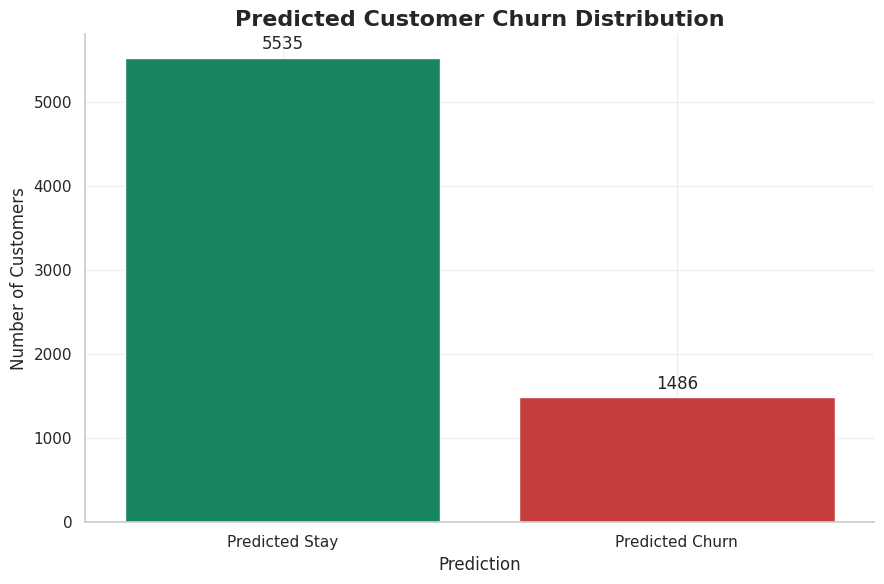

In [60]:
plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df_predictions,
    x="PredictedChurnLabel",
    order=[
        "Predicted Stay",
        "Predicted Churn"
    ],
    palette=[
        SECONDARY,
        DANGER
    ]
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

style_chart(
    "Predicted Customer Churn Distribution",
    "Prediction",
    "Number of Customers"
)

plt.show()

# Churn probability distribution

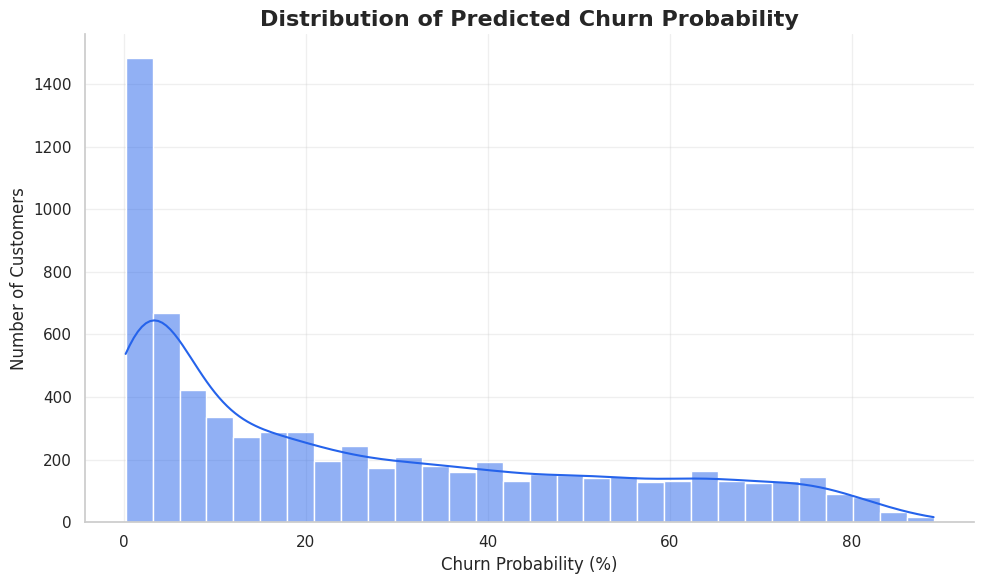

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_predictions,
    x="ChurnProbabilityPercent",
    bins=30,
    kde=True,
    color=PRIMARY
)

style_chart(
    "Distribution of Predicted Churn Probability",
    "Churn Probability (%)",
    "Number of Customers"
)

plt.show()

# Final prediction validation

In [64]:
required_prediction_columns = [
    "ActualChurn",
    "ActualChurnLabel",
    "PredictedChurnClass",
    "PredictedChurnLabel",
    "ChurnProbability",
    "ChurnProbabilityPercent"
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in df_predictions.columns
]

print("=" * 60)
print("PREDICTION DATASET VALIDATION")
print("=" * 60)

print(f"Rows              : {df_predictions.shape[0]:,}")
print(f"Columns           : {df_predictions.shape[1]:,}")
print(
    f"Missing Values    : "
    f"{df_predictions[required_prediction_columns].isnull().sum().sum():,}"
)
print(
    f"Missing Columns   : "
    f"{len(missing_prediction_columns)}"
)

if not missing_prediction_columns:
    print("Prediction dataset created successfully.")
else:
    print("Prediction dataset validation failed.")

PREDICTION DATASET VALIDATION
Rows              : 7,021
Columns           : 40
Missing Values    : 0
Missing Columns   : 0
Prediction dataset created successfully.


## Business Interpretation

The production model generated an individual churn probability for every customer.

Unlike a simple predicted class, churn probability provides a continuous measure of risk. This enables the organization to rank customers from lowest to highest risk and allocate retention resources more effectively.

Customers with probabilities close to 100% represent the strongest candidates for immediate intervention, while customers with lower probabilities may require routine monitoring rather than urgent action.

The merged prediction dataset now combines machine learning outputs with customer financial, loyalty, service, value, and risk indicators.

## Section Summary

The production model successfully generated churn predictions and probabilities for all customers.

The prediction outputs were merged with the business-readable feature-engineered dataset, creating a comprehensive customer intelligence table containing:

- Actual churn outcomes
- Predicted churn classes
- Predicted churn labels
- Individual churn probabilities
- Customer value indicators
- Loyalty indicators
- Service-engagement indicators
- Business risk scores

The completed prediction dataset is now ready for customer risk ranking and retention-priority analysis.

# Section 4 — **Customer Risk Ranking**


Predicting customer churn is only the first step in an effective customer retention strategy.

To maximize business impact, organizations must identify which customers require immediate attention based on their estimated probability of churn.

This section ranks customers according to their predicted churn probability, allowing business stakeholders to prioritize retention efforts and allocate resources efficiently.

The ranking provides an actionable customer risk list that supports proactive customer engagement and targeted retention campaigns.

The resulting customer risk table will become one of the primary outputs of the AI-Powered Customer Retention Intelligence Platform.

## Objectives

This section performs the following tasks:

- Rank customers by predicted churn probability.
- Create customer risk categories.
- Assign business priority levels.
- Identify high-risk customers.
- Visualize customer risk distribution.
- Generate executive risk summaries.

# Rank Customers

In [65]:
df_predictions = df_predictions.sort_values(

    by="ChurnProbability",

    ascending=False

).reset_index(drop=True)

df_predictions["CustomerRiskRank"] = (

    df_predictions.index + 1

)

print("Customer risk ranking created successfully.")

display(

    df_predictions[
        [

            "CustomerRiskRank",

            "ChurnProbabilityPercent"

        ]

    ].head()

)

Customer risk ranking created successfully.


,CustomerRiskRank,ChurnProbabilityPercent
0,1,88.9700
1,2,88.5600
2,3,87.8900
3,4,87.7800
4,5,87.7800


# Risk Categories

In [66]:

risk_bins = [

    0,

    0.25,

    0.50,

    0.75,

    1.00

]

risk_labels = [

    "Low",

    "Moderate",

    "High",

    "Critical"

]

df_predictions["RiskCategory"] = pd.cut(

    df_predictions["ChurnProbability"],

    bins=risk_bins,

    labels=risk_labels,

    include_lowest=True

)

display(

    df_predictions[
        [

            "ChurnProbabilityPercent",

            "RiskCategory"

        ]

    ].head()

)

,ChurnProbabilityPercent,RiskCategory
0,88.9700,Critical
1,88.5600,Critical
2,87.8900,Critical
3,87.7800,Critical
4,87.7800,Critical


# Executive Priority

In [67]:

priority_conditions = [

    df_predictions["ChurnProbability"] >= 0.80,

    df_predictions["ChurnProbability"] >= 0.60,

    df_predictions["ChurnProbability"] >= 0.40

]

priority_labels = [

    "Immediate Action",

    "High Priority",

    "Monitor"

]

df_predictions["RetentionPriority"] = np.select(

    priority_conditions,

    priority_labels,

    default="Low Priority"

)

display(

    df_predictions[
        [

            "RiskCategory",

            "RetentionPriority"

        ]

    ].head()

)

,RiskCategory,RetentionPriority
0,Critical,Immediate Action
1,Critical,Immediate Action
2,Critical,Immediate Action
3,Critical,Immediate Action
4,Critical,Immediate Action


# Top 20 Highest Risk Customers

In [69]:

top20 = df_predictions.head(20)

display(

    top20[

        [

            "CustomerRiskRank",

            "ChurnProbabilityPercent",

            "RiskCategory",

            "RetentionPriority"

        ]

    ]

)

,CustomerRiskRank,ChurnProbabilityPercent,RiskCategory,RetentionPriority
0,1,88.9700,Critical,Immediate Action
1,2,88.5600,Critical,Immediate Action
2,3,87.8900,Critical,Immediate Action
3,4,87.7800,Critical,Immediate Action
4,5,87.7800,Critical,Immediate Action
5,6,87.5500,Critical,Immediate Action
6,7,87.5000,Critical,Immediate Action
7,8,87.4800,Critical,Immediate Action
8,9,87.4100,Critical,Immediate Action
9,10,87.3600,Critical,Immediate Action


# Risk Distribution

In [71]:

risk_summary = (

    df_predictions["RiskCategory"]

    .value_counts()

    .sort_index()

)

display(risk_summary)

,count
RiskCategory,
Low,4055
Moderate,1480
High,1158
Critical,328


# Risk Distribution Chart

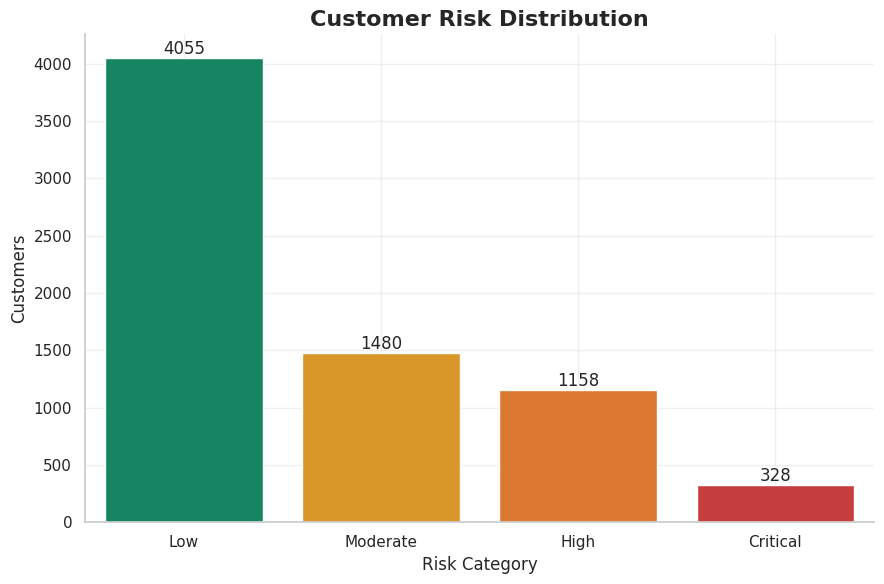

In [73]:

plt.figure(figsize=(9,6))

ax = sns.countplot(

    data=df_predictions,

    x="RiskCategory",

    hue="RiskCategory",

    palette=[

        SECONDARY,

        WARNING,

        "#F97316",

        DANGER

    ],

    legend=False

)

for container in ax.containers:

    ax.bar_label(container)

style_chart(

    "Customer Risk Distribution",

    "Risk Category",

    "Customers"

)

plt.show()

In [74]:
# ============================================================
# Executive KPIs
# ============================================================

summary = pd.DataFrame({

    "Metric":[

        "Total Customers",

        "Critical Risk",

        "High Risk",

        "Moderate Risk",

        "Low Risk"

    ],

    "Value":[

        len(df_predictions),

        (df_predictions["RiskCategory"]=="Critical").sum(),

        (df_predictions["RiskCategory"]=="High").sum(),

        (df_predictions["RiskCategory"]=="Moderate").sum(),

        (df_predictions["RiskCategory"]=="Low").sum()

    ]

})

display(summary)

,Metric,Value
0,Total Customers,7021
1,Critical Risk,328
2,High Risk,1158
3,Moderate Risk,1480
4,Low Risk,4055


# Top 10 Highest Churn Probability

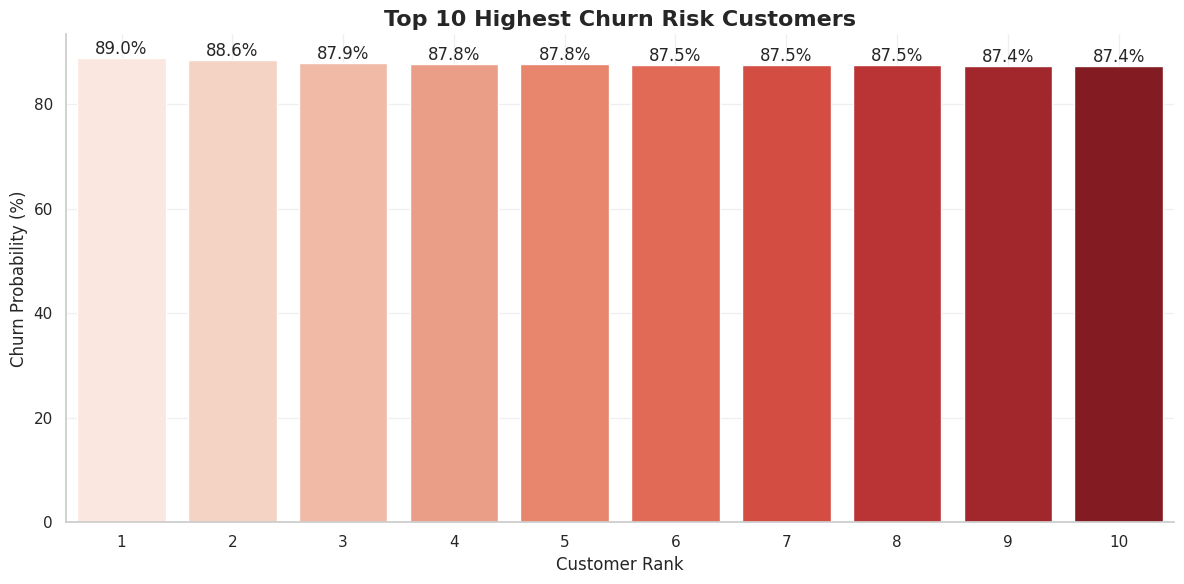

In [76]:

plt.figure(figsize=(12,6))

top10 = df_predictions.head(10)

ax = sns.barplot(

    x=top10["CustomerRiskRank"].astype(str),

    y=top10["ChurnProbabilityPercent"],

    palette="Reds"

)

for container in ax.containers:

    ax.bar_label(

        container,

        fmt="%.1f%%"

    )

style_chart(

    "Top 10 Highest Churn Risk Customers",

    "Customer Rank",

    "Churn Probability (%)"

)

plt.show()

## Business Interpretation

Customer risk ranking transforms machine learning predictions into an actionable business tool.

Rather than treating all customers equally, the organization can prioritize retention activities based on estimated churn probability.

Customers classified as **Critical Risk** should receive immediate attention, while **High Risk** customers should be monitored closely through personalized retention campaigns.

This ranking enables efficient allocation of marketing resources and supports proactive customer relationship management.

## Recommendations

Organizations should prioritize customers with the highest predicted churn probabilities.

Recommended actions include:

- Immediate outreach to Critical Risk customers.
- Personalized loyalty offers for High Risk customers.
- Monitor Moderate Risk customers through periodic engagement.
- Continue standard customer service for Low Risk customers.

Using customer risk ranking enables organizations to maximize retention efforts while minimizing unnecessary intervention costs.

# Section 5 — **Business Segmentation**


Predicting customer churn alone is not sufficient for effective business decision-making.

Organizations must also consider customer value when prioritizing retention efforts. A customer with a high probability of churn may not require the same level of intervention as a high-value customer with an equally high churn risk.

This section combines predicted churn probability with customer value indicators to create meaningful business segments.

The resulting customer segments provide a strategic framework for retention planning, marketing campaigns, resource allocation, and executive decision-making.

These business segments transform predictive analytics into actionable customer intelligence.

## Objectives

This section performs the following tasks:

- Segment customers according to business value.
- Combine customer value with churn probability.
- Create strategic customer groups.
- Visualize customer segments.
- Generate executive customer summaries.
- Support targeted retention strategies.

# Create Customer Value Groups

In [77]:

median_value = df_predictions["CustomerValueScore"].median()

df_predictions["CustomerValueGroup"] = np.where(

    df_predictions["CustomerValueScore"] >= median_value,

    "High Value",

    "Low Value"

)

display(

    df_predictions[

        [

            "CustomerValueScore",

            "CustomerValueGroup"

        ]

    ].head()

)

,CustomerValueScore,CustomerValueGroup
0,13.0900,Low Value
1,10.5600,Low Value
2,10.5500,Low Value
3,10.5500,Low Value
4,12.2600,Low Value


# Create Business Segments

In [79]:

conditions = [

    (df_predictions["CustomerValueGroup"]=="High Value") &
    (df_predictions["RiskCategory"].isin(["High","Critical"])),

    (df_predictions["CustomerValueGroup"]=="High Value") &
    (df_predictions["RiskCategory"].isin(["Low","Moderate"])),

    (df_predictions["CustomerValueGroup"]=="Low Value") &
    (df_predictions["RiskCategory"].isin(["High","Critical"])),

    (df_predictions["CustomerValueGroup"]=="Low Value") &
    (df_predictions["RiskCategory"].isin(["Low","Moderate"]))

]

choices = [

    "Protect Immediately",

    "Maintain Relationship",

    "Retention Opportunity",

    "Standard Service"

]

df_predictions["BusinessSegment"] = np.select(

    conditions,

    choices,

    default="Standard Service"

)

display(

    df_predictions[

        [

            "CustomerValueGroup",

            "RiskCategory",

            "BusinessSegment"

        ]

    ].head()

)

,CustomerValueGroup,RiskCategory,BusinessSegment
0,Low Value,Critical,Retention Opportunity
1,Low Value,Critical,Retention Opportunity
2,Low Value,Critical,Retention Opportunity
3,Low Value,Critical,Retention Opportunity
4,Low Value,Critical,Retention Opportunity


In [81]:

segment_summary = (

    df_predictions["BusinessSegment"]

    .value_counts()

    .to_frame("Customers")

)

segment_summary["Percentage (%)"] = (

    segment_summary["Customers"]

    / len(df_predictions)

    *100

).round(2)

display(segment_summary)

,Customers,Percentage (%)
BusinessSegment,,
Maintain Relationship,3274,46.6300
Standard Service,2261,32.2000
Retention Opportunity,1249,17.7900
Protect Immediately,237,3.3800


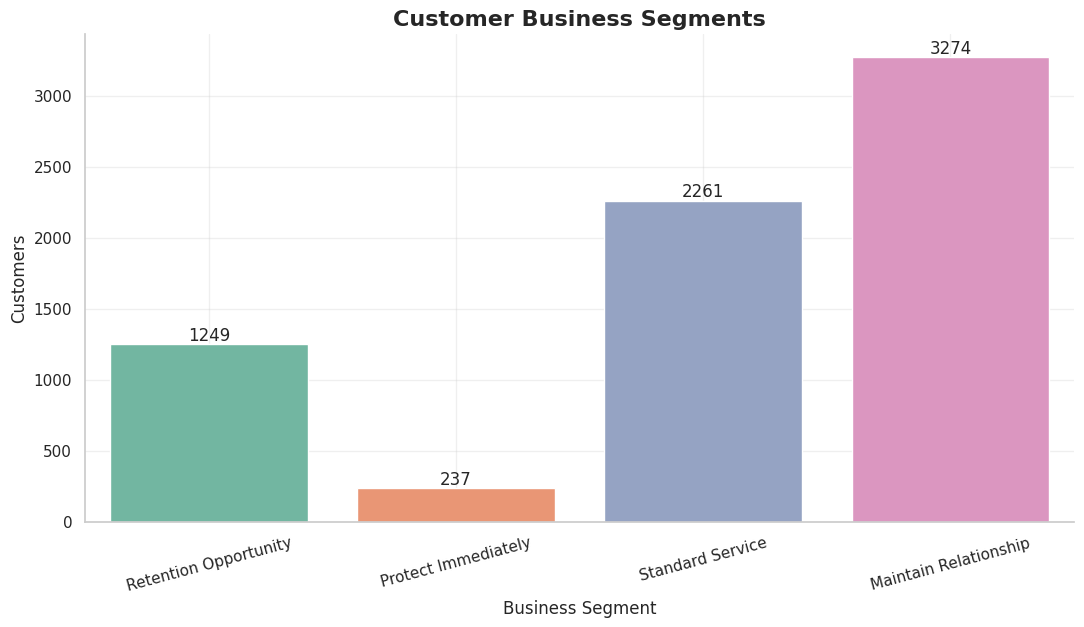

In [83]:
# Business Segment Distribution

plt.figure(figsize=(11,6))

ax = sns.countplot(

    data=df_predictions,

    x="BusinessSegment",

    hue="BusinessSegment",

    palette="Set2",

    legend=False

)

for container in ax.containers:

    ax.bar_label(container)

style_chart(

    "Customer Business Segments",

    "Business Segment",

    "Customers"

)

plt.xticks(rotation=15)

plt.show()

In [85]:
# Value vs Risk Matrix

matrix = pd.crosstab(

    df_predictions["CustomerValueGroup"],

    df_predictions["RiskCategory"]

)

display(matrix)

RiskCategory,Low,Moderate,High,Critical
CustomerValueGroup,,,,
High Value,2655,619,237,0
Low Value,1400,861,921,328


# Heatmap

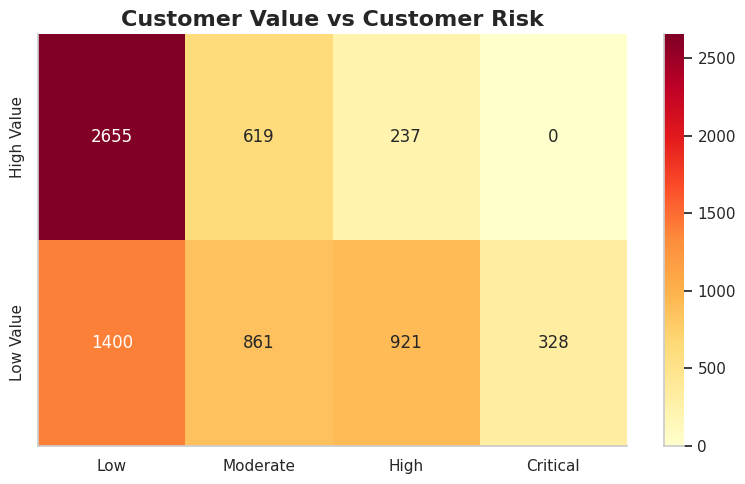

In [87]:

plt.figure(figsize=(8,5))

sns.heatmap(

    matrix,

    annot=True,

    cmap="YlOrRd",

    fmt="d"

)

style_chart(

    "Customer Value vs Customer Risk"

)

plt.show()

# Executive Dashboard

In [89]:
dashboard = pd.DataFrame({

    "Business Segment":[

        "Protect Immediately",

        "Maintain Relationship",

        "Retention Opportunity",

        "Standard Service"

    ],

    "Customers":[

        (df_predictions["BusinessSegment"]=="Protect Immediately").sum(),

        (df_predictions["BusinessSegment"]=="Maintain Relationship").sum(),

        (df_predictions["BusinessSegment"]=="Retention Opportunity").sum(),

        (df_predictions["BusinessSegment"]=="Standard Service").sum()

    ]

})

display(dashboard)

,Business Segment,Customers
0,Protect Immediately,237
1,Maintain Relationship,3274
2,Retention Opportunity,1249
3,Standard Service,2261


## Business Interpretation

Customer segmentation combines predictive analytics with customer value to create actionable business intelligence.

Customers classified as **Protect Immediately** represent the highest-value customers who also exhibit elevated churn risk. These customers should receive immediate retention efforts because losing them would have the greatest business impact.

Customers categorized as **Maintain Relationship** are valuable customers with relatively low churn risk and should remain engaged through loyalty initiatives.

Customers identified as **Retention Opportunity** may benefit from lower-cost retention campaigns, while **Standard Service** customers require routine customer management.

This segmentation enables organizations to allocate retention resources according to both customer value and predicted business risk.

## Recommendations

Organizations should prioritize customer retention investments according to business segment.

Recommended actions include:

- Protect Immediately → Dedicated retention specialists, personalized offers, executive outreach.
- Maintain Relationship → Loyalty rewards, premium services, periodic engagement.
- Retention Opportunity → Cost-effective promotional campaigns and service improvements.
- Standard Service → Continue regular customer support and monitor future risk.

This segmentation framework supports efficient resource allocation and maximizes customer lifetime value.

## Section Summary

Customer segmentation successfully combined customer value and predicted churn risk to create actionable business groups.

The resulting business segments provide a strategic decision-support framework for customer retention planning, executive reporting, and marketing prioritization.

By integrating machine learning predictions with customer value indicators, the organization can focus retention efforts where they generate the greatest business impact.

The next section will explore **Model Explainability**, examining which customer characteristics contributed most strongly to the model's predictions and increasing trust in the AI-powered decision-making process.

# Section 6 — **Model Explainability**


Accurate predictions alone are not sufficient for effective business decision-making. Organizations also need to understand the reasons behind those predictions.

Model explainability helps identify the customer characteristics that contribute most to churn prediction, increasing transparency and confidence in the machine learning model.

This section analyzes feature importance from the selected production model and identifies the variables that have the greatest influence on customer churn.

The resulting insights support explainable artificial intelligence (XAI), improve stakeholder trust, and guide strategic customer retention initiatives.

## Objectives

This section performs the following tasks:

- Identify the most influential predictive features.
- Rank feature importance.
- Visualize important customer characteristics.
- Interpret model behavior.
- Translate AI findings into business insights.

# Feature Importance

In [93]:
# Different models store feature importance differently

if hasattr(production_model, "feature_importances_"):

    importance_values = production_model.feature_importances_

elif hasattr(production_model, "coef_"):

    importance_values = np.abs(production_model.coef_[0])

else:

    raise AttributeError(
        "This model does not support feature importance."
    )

feature_importance = pd.DataFrame({

    "Feature": model_feature_names,

    "Importance": importance_values

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

display(feature_importance.head(20))

,Feature,Importance
24,MultipleLines_No,0.3218
55,PaymentMethod_Electronic check,0.3049
58,TenureCategory_Developing Customer,0.2448
0,SeniorCitizen,0.2358
23,PhoneService_Yes,0.2253
25,MultipleLines_No phone service,0.2242
22,PhoneService_No,0.2242
51,PaperlessBilling_No,0.2003
52,PaperlessBilling_Yes,0.1991
57,TenureCategory_New Customer,0.1929


# Top 20 Features

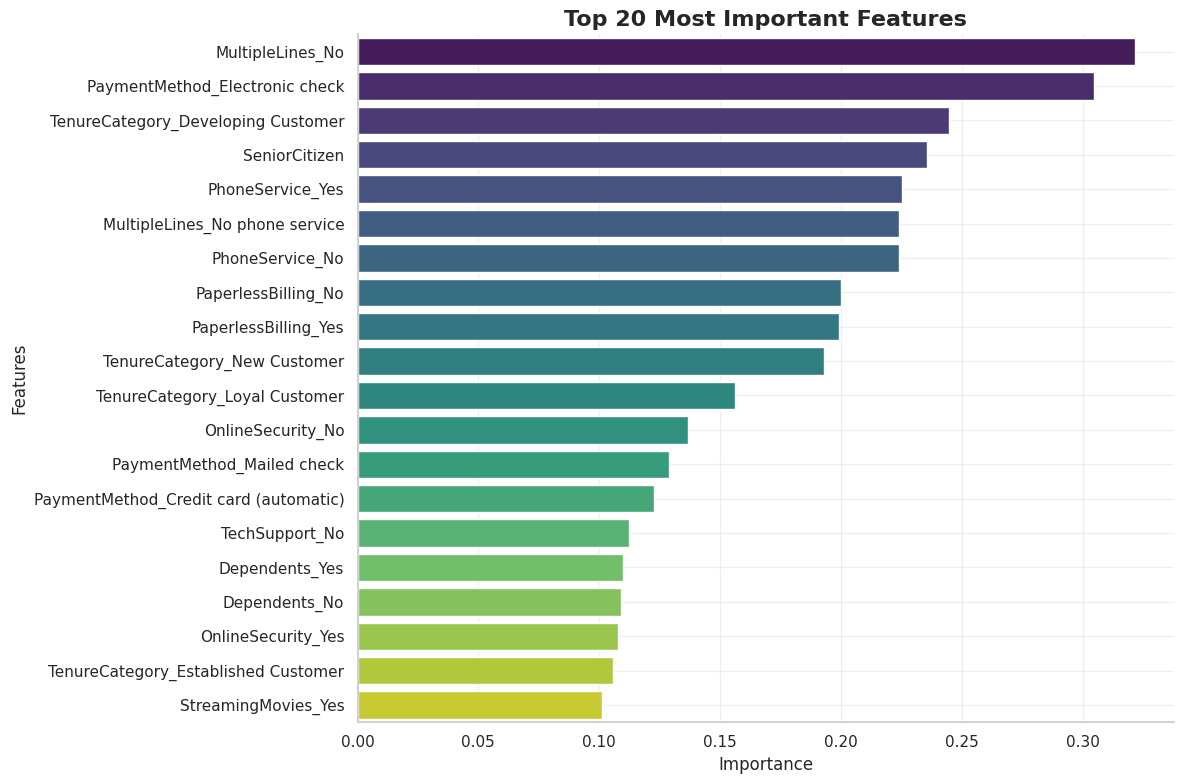

In [95]:
top20 = feature_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(

    data=top20,

    x="Importance",

    y="Feature",

    palette="viridis"

)

style_chart(

    "Top 20 Most Important Features",

    "Importance",

    "Features"

)

plt.show()

# Engineered Features Only

In [97]:

engineered_features = [

    "CustomerLifetimeValue",

    "EstimatedAnnualRevenue",

    "AverageMonthlySpend",

    "LoyaltyScore",

    "ServiceCount",

    "SupportUsageScore",

    "RetentionScore",

    "CustomerValueScore",

    "CustomerRiskScore"

]

engineered_importance = feature_importance[

    feature_importance["Feature"]

    .isin(engineered_features)

]

display(engineered_importance)

,Feature,Importance
11,SupportUsageScore,0.0650
8,LoyaltyScore,0.0595
14,CustomerValueScore,0.0347
10,RetentionScore,0.0190
9,ServiceCount,0.0057
15,CustomerRiskScore,0.0029
5,EstimatedAnnualRevenue,0.0018
4,CustomerLifetimeValue,0.0004
6,AverageMonthlySpend,0.0002


# Engineered Feature Importance

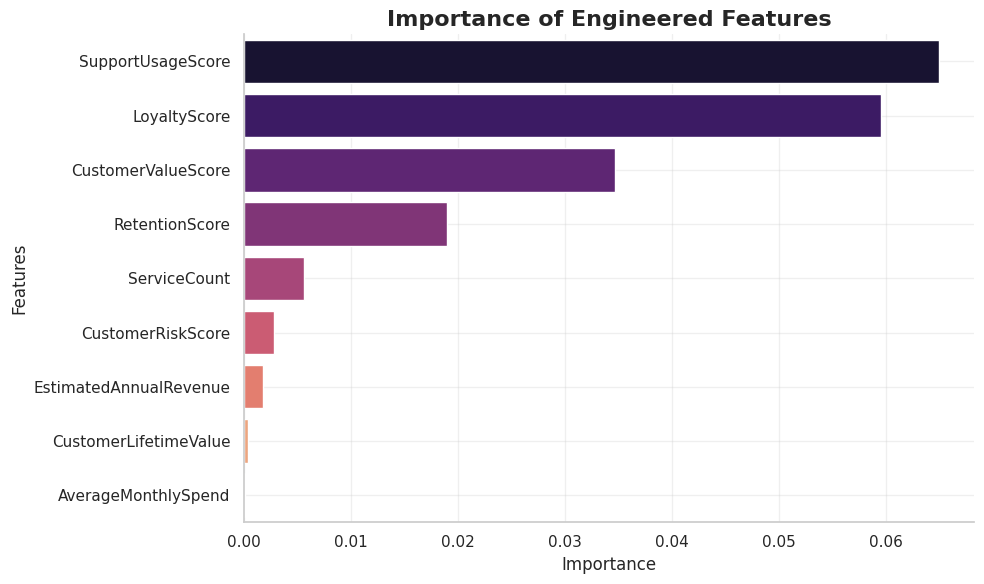

In [99]:

plt.figure(figsize=(10,6))

sns.barplot(

    data=engineered_importance,

    x="Importance",

    y="Feature",

    palette="magma"

)

style_chart(

    "Importance of Engineered Features",

    "Importance",

    "Features"

)

plt.show()

# Top 10 Business Drivers

In [101]:
business_drivers = feature_importance.head(10)

display(business_drivers)

,Feature,Importance
24,MultipleLines_No,0.3218
55,PaymentMethod_Electronic check,0.3049
58,TenureCategory_Developing Customer,0.2448
0,SeniorCitizen,0.2358
23,PhoneService_Yes,0.2253
25,MultipleLines_No phone service,0.2242
22,PhoneService_No,0.2242
51,PaperlessBilling_No,0.2003
52,PaperlessBilling_Yes,0.1991
57,TenureCategory_New Customer,0.1929


# Executive Dashboard

In [103]:

dashboard = business_drivers.copy()

dashboard["Rank"] = range(

    1,

    len(dashboard)+1

)

display(

    dashboard[

        [

            "Rank",

            "Feature",

            "Importance"

        ]

    ]

)

,Rank,Feature,Importance
24,1,MultipleLines_No,0.3218
55,2,PaymentMethod_Electronic check,0.3049
58,3,TenureCategory_Developing Customer,0.2448
0,4,SeniorCitizen,0.2358
23,5,PhoneService_Yes,0.2253
25,6,MultipleLines_No phone service,0.2242
22,7,PhoneService_No,0.2242
51,8,PaperlessBilling_No,0.2003
52,9,PaperlessBilling_Yes,0.1991
57,10,TenureCategory_New Customer,0.1929


# Cumulative Importance

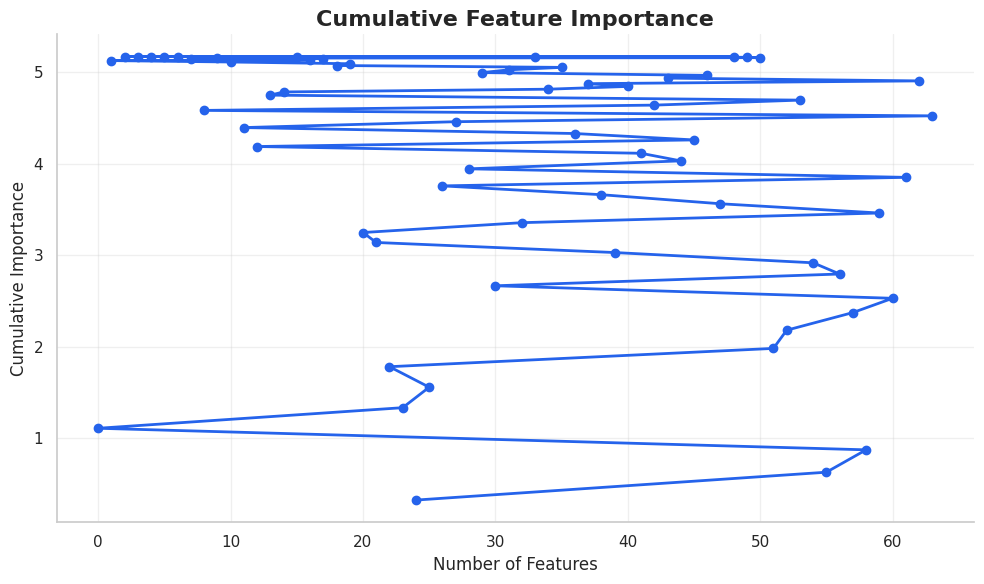

In [105]:

feature_importance["CumulativeImportance"] = (

    feature_importance["Importance"]

    .cumsum()

)

plt.figure(figsize=(10,6))

plt.plot(

    feature_importance["CumulativeImportance"],

    marker="o",

    linewidth=2,

    color=PRIMARY

)

style_chart(

    "Cumulative Feature Importance",

    "Number of Features",

    "Cumulative Importance"

)

plt.show()

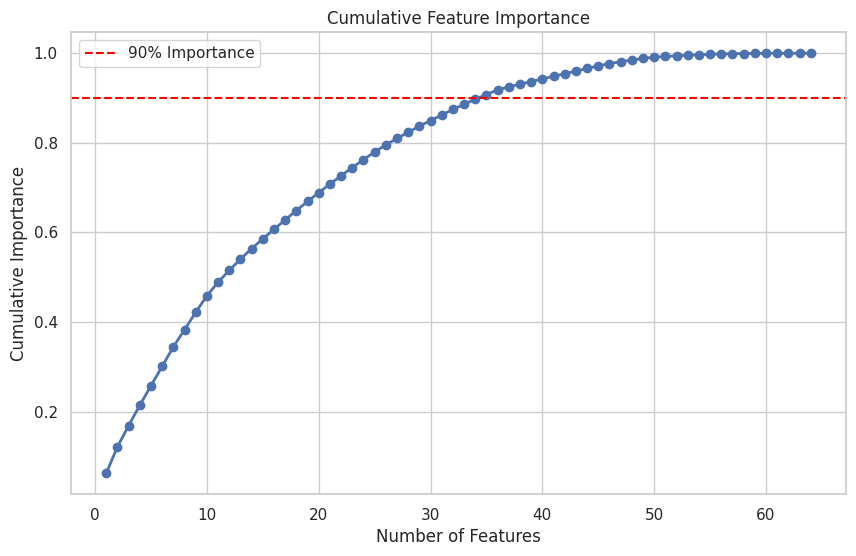

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# Logistic Regression
importance = np.abs(production_model.coef_[0])

# Sort from most important to least important
sorted_idx = np.argsort(importance)[::-1]
sorted_importance = importance[sorted_idx]

# Normalize
sorted_importance = sorted_importance / sorted_importance.sum()

# Cumulative importance
cumulative_importance = np.cumsum(sorted_importance)

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(cumulative_importance)+1),
    cumulative_importance,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance")
plt.grid(True)
plt.axhline(0.90, color='red', linestyle='--', label='90% Importance')
plt.legend()
plt.show()

# Top 5 AI Insights

In [107]:

print("="*60)
print("TOP AI BUSINESS INSIGHTS")
print("="*60)

for i, row in feature_importance.head(5).iterrows():

    print(

        f"{i+1}. "

        f"{row['Feature']} "

        f"(Importance = {row['Importance']:.4f})"

    )

TOP AI BUSINESS INSIGHTS
25. MultipleLines_No (Importance = 0.3218)
56. PaymentMethod_Electronic check (Importance = 0.3049)
59. TenureCategory_Developing Customer (Importance = 0.2448)
1. SeniorCitizen (Importance = 0.2358)
24. PhoneService_Yes (Importance = 0.2253)


## Business Interpretation

The feature importance analysis reveals the customer characteristics that most strongly influence churn prediction.

Variables with higher importance scores contribute more significantly to the model's decision-making process.

The presence of engineered features among the most influential predictors demonstrates that feature engineering successfully enhanced the predictive capability of the machine learning model.

These findings help explain why customers are classified as high-risk and provide valuable guidance for customer retention initiatives.

##  Recommendations

Organizations should prioritize business strategies associated with the most influential predictive features.

Examples include:

- Strengthening customer loyalty programs.
- Improving technical support services.
- Encouraging long-term contracts.
- Increasing customer engagement.
- Monitoring high-value customers with elevated churn risk.

Explainable AI enables business stakeholders to understand model decisions and develop targeted retention strategies based on evidence rather than assumptions.

## Section Summary

The production model's feature importance was successfully analyzed.

The analysis identified the customer characteristics that contribute most significantly to churn prediction and demonstrated the effectiveness of the engineered features created during Notebook 4.

These insights improve transparency, support explainable artificial intelligence, and provide actionable business intelligence for customer retention planning.

The next section will build an **Executive Business Dashboard**, presenting key performance indicators, customer segmentation, churn risk, and business intelligence visualizations in a management-friendly format.

# Section 7 — **Executive Business Dashboard**


The Executive Business Dashboard summarizes the most important outputs from the customer churn prediction system in a clear and decision-oriented format.

Rather than presenting technical model outputs alone, this section converts prediction results into key performance indicators, customer risk summaries, business segments, and retention priorities that can be understood by business stakeholders.

The dashboard is designed to answer the following executive questions:

- How many customers are currently analyzed?
- How many customers are predicted to churn?
- What is the average predicted churn probability?
- How many customers are classified as high or critical risk?
- How many high-value customers require immediate intervention?
- Which business segments should receive the greatest attention?
- How should retention resources be prioritized?

The results provide a management-level overview of customer retention risk and support data-driven decision-making.

## Objectives

This section performs the following tasks:

- Calculate executive customer-retention KPIs.
- Summarize customer risk categories.
- Summarize retention-priority groups.
- Analyze business-segment distribution.
- Identify high-value customers at risk.
- Create professional executive visualizations.
- Produce a management-ready dashboard summary.

# Validate dashboard requirements

In [109]:

required_dashboard_columns = [
    "PredictedChurnClass",
    "PredictedChurnLabel",
    "ChurnProbability",
    "ChurnProbabilityPercent",
    "RiskCategory",
    "RetentionPriority",
    "CustomerValueScore",
    "CustomerValueGroup",
    "BusinessSegment"
]

missing_dashboard_columns = [
    column
    for column in required_dashboard_columns
    if column not in df_predictions.columns
]

if missing_dashboard_columns:
    print("Missing dashboard columns:")
    for column in missing_dashboard_columns:
        print(f"- {column}")
else:
    print("All dashboard requirements are available.")

All dashboard requirements are available.


# Calculate dashboard KPIs

In [114]:

total_customers = len(df_predictions)

predicted_churn_customers = (
    df_predictions["PredictedChurnClass"] == 1
).sum()

predicted_stay_customers = (
    df_predictions["PredictedChurnClass"] == 0
).sum()

predicted_churn_rate = (
    predicted_churn_customers / total_customers * 100
)

average_churn_probability = (
    df_predictions["ChurnProbability"].mean() * 100
)

high_critical_risk_customers = (
    df_predictions["RiskCategory"]
    .isin(["High", "Critical"])
).sum()

immediate_action_customers = (
    df_predictions["RetentionPriority"]
    == "Immediate Action"
).sum()

high_value_at_risk = (
    (
        df_predictions["CustomerValueGroup"] == "High Value"
    )
    &
    (
        df_predictions["RiskCategory"]
        .isin(["High", "Critical"])
    )
).sum()

print("Executive KPIs calculated successfully.")

Executive KPIs calculated successfully.


In [116]:
# Executive KPI Table

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Predicted to Stay",
        "Predicted to Churn",
        "Predicted Churn Rate",
        "Average Churn Probability",
        "High or Critical Risk Customers",
        "Immediate Action Customers",
        "High-Value Customers at Risk"
    ],
    "Value": [
        f"{total_customers:,}",
        f"{predicted_stay_customers:,}",
        f"{predicted_churn_customers:,}",
        f"{predicted_churn_rate:.2f}%",
        f"{average_churn_probability:.2f}%",
        f"{high_critical_risk_customers:,}",
        f"{immediate_action_customers:,}",
        f"{high_value_at_risk:,}"
    ]
})

display(executive_kpis)

,KPI,Value
0,Total Customers,"7,021"
1,Predicted to Stay,"5,535"
2,Predicted to Churn,"1,486"
3,Predicted Churn Rate,21.17%
4,Average Churn Probability,26.35%
5,High or Critical Risk Customers,"1,486"
6,Immediate Action Customers,131
7,High-Value Customers at Risk,237


# KPI visualization

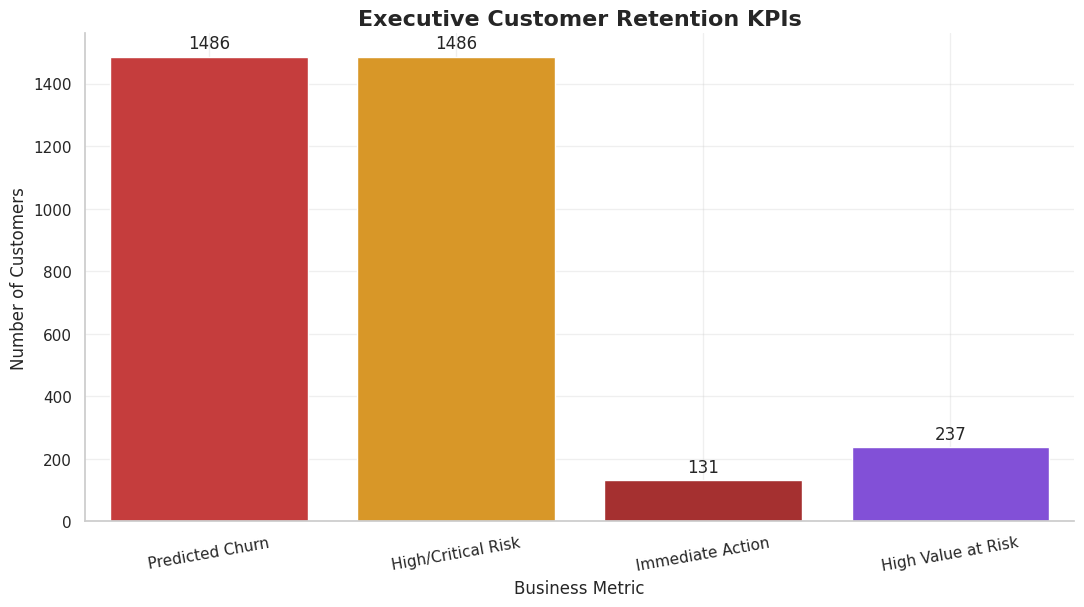

In [118]:

kpi_chart = pd.DataFrame({
    "Metric": [
        "Predicted Churn",
        "High/Critical Risk",
        "Immediate Action",
        "High Value at Risk"
    ],
    "Customers": [
        predicted_churn_customers,
        high_critical_risk_customers,
        immediate_action_customers,
        high_value_at_risk
    ]
})

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=kpi_chart,
    x="Metric",
    y="Customers",
    hue="Metric",
    palette=[
        DANGER,
        WARNING,
        "#B91C1C",
        PURPLE
    ],
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fmt="%.0f"
    )

style_chart(
    "Executive Customer Retention KPIs",
    "Business Metric",
    "Number of Customers"
)

plt.xticks(rotation=10)
plt.show()

## Predicted Customer Status

This analysis compares the number of customers predicted to remain with the company against those predicted to churn.

The result provides an overall view of the model-estimated customer retention outlook.

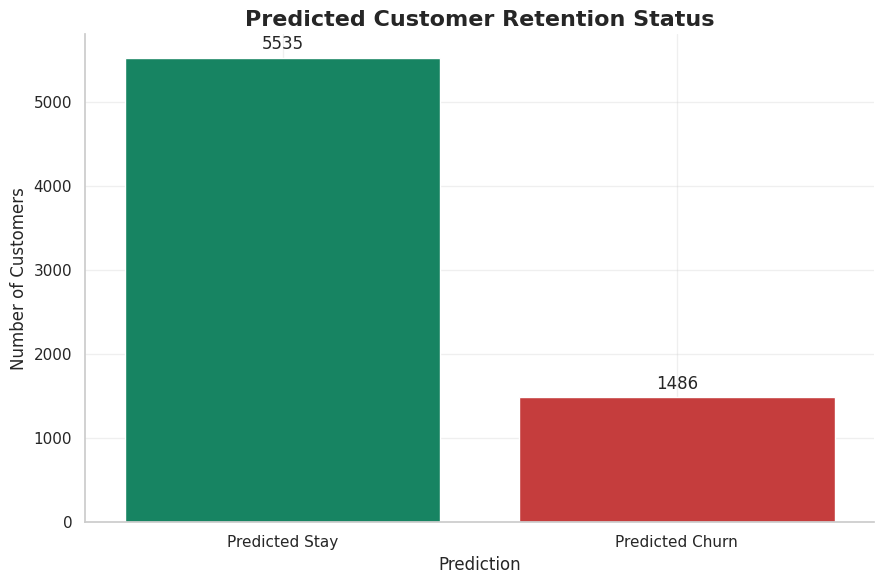

In [120]:
# Predicted Customer Status

status_order = [
    "Predicted Stay",
    "Predicted Churn"
]

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df_predictions,
    x="PredictedChurnLabel",
    order=status_order,
    hue="PredictedChurnLabel",
    palette={
        "Predicted Stay": SECONDARY,
        "Predicted Churn": DANGER
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

style_chart(
    "Predicted Customer Retention Status",
    "Prediction",
    "Number of Customers"
)

plt.show()

## Customer Risk Distribution

The customer risk distribution shows how customers are allocated across low, moderate, high, and critical churn-risk categories.

This enables management to understand the size of each risk group and determine the level of retention resources required.

In [121]:
# Risk Category Summary

risk_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

risk_dashboard = (
    df_predictions["RiskCategory"]
    .value_counts()
    .reindex(risk_order, fill_value=0)
    .rename_axis("Risk Category")
    .to_frame("Customers")
)

risk_dashboard["Percentage (%)"] = (
    risk_dashboard["Customers"]
    .div(total_customers)
    .mul(100)
    .round(2)
)

display(risk_dashboard)

,Customers,Percentage (%)
Risk Category,,
Low,4055,57.7600
Moderate,1480,21.0800
High,1158,16.4900
Critical,328,4.6700


# Risk distribution chart

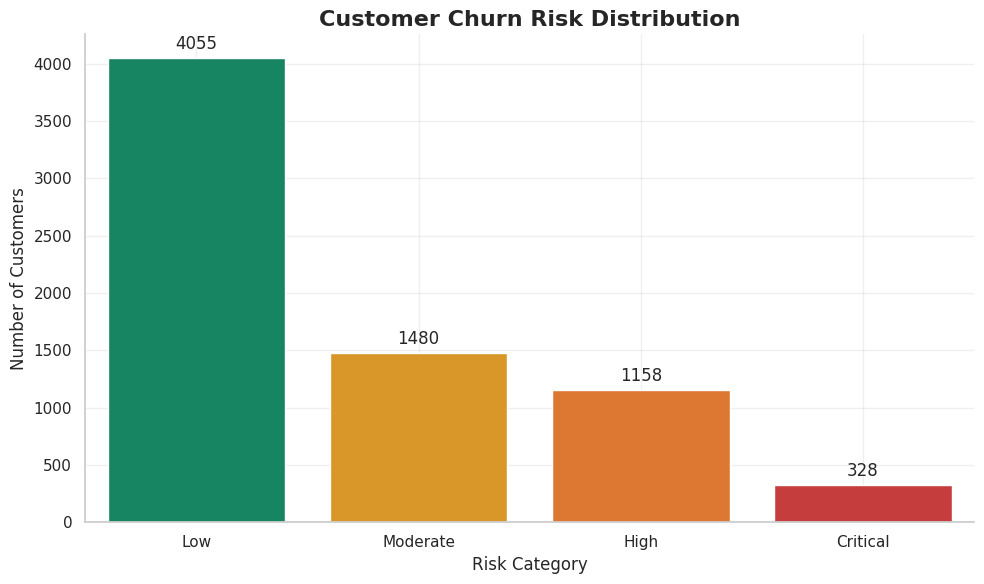

In [123]:
# Customer Risk Distribution Chart

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_predictions,
    x="RiskCategory",
    order=risk_order,
    hue="RiskCategory",
    palette={
        "Low": SECONDARY,
        "Moderate": WARNING,
        "High": "#F97316",
        "Critical": DANGER
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

style_chart(
    "Customer Churn Risk Distribution",
    "Risk Category",
    "Number of Customers"
)

plt.show()

## Retention Priority Overview

Retention priorities translate churn probabilities into practical business action levels.

Customers requiring immediate action should receive the fastest and most personalized interventions, while lower-priority customers can be managed using standard engagement programs.

In [125]:
# Retention Priority Summary

priority_order = [
    "Low Priority",
    "Monitor",
    "High Priority",
    "Immediate Action"
]

priority_dashboard = (
    df_predictions["RetentionPriority"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
    .rename_axis("Retention Priority")
    .to_frame("Customers")
)

priority_dashboard["Percentage (%)"] = (
    priority_dashboard["Customers"]
    .div(total_customers)
    .mul(100)
    .round(2)
)

display(priority_dashboard)

,Customers,Percentage (%)
Retention Priority,,
Low Priority,5000,71.2100
Monitor,1005,14.3100
High Priority,885,12.6100
Immediate Action,131,1.8700


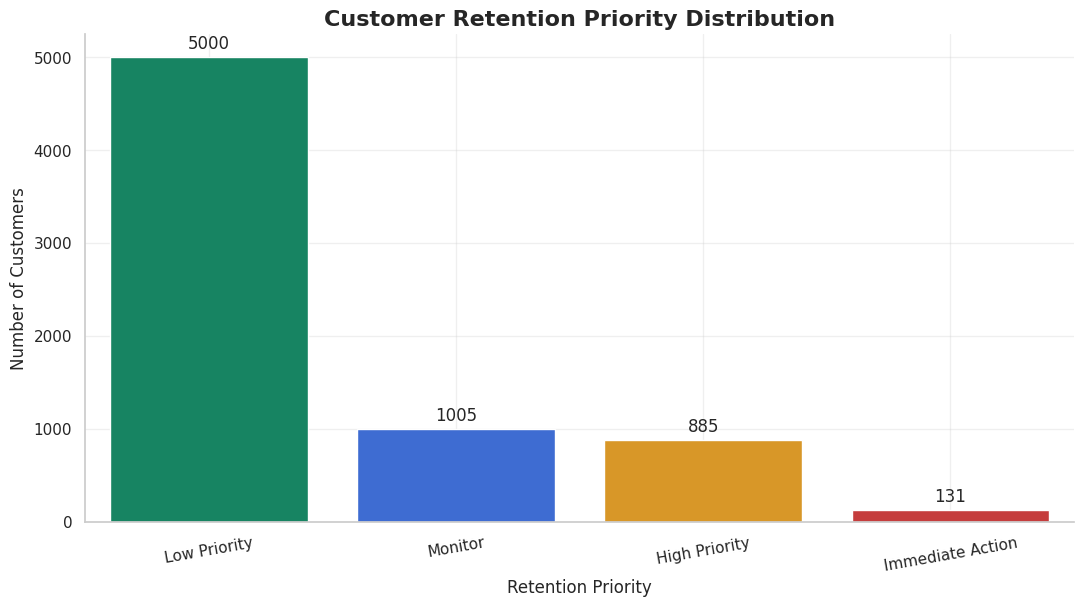

In [127]:
# Retention Priority Distribution

plt.figure(figsize=(11, 6))

ax = sns.countplot(
    data=df_predictions,
    x="RetentionPriority",
    order=priority_order,
    hue="RetentionPriority",
    palette={
        "Low Priority": SECONDARY,
        "Monitor": PRIMARY,
        "High Priority": WARNING,
        "Immediate Action": DANGER
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

style_chart(
    "Customer Retention Priority Distribution",
    "Retention Priority",
    "Number of Customers"
)

plt.xticks(rotation=10)
plt.show()

## Business Segment Overview

Business segmentation combines customer value and churn risk to identify the strategic importance of each customer group.

The resulting segments allow management to distinguish between customers who require urgent intervention, customers who should receive loyalty support, customers suitable for cost-effective retention offers, and customers who require standard service.

In [128]:
# Business Segment Summary

segment_order = [
    "Protect Immediately",
    "Maintain Relationship",
    "Retention Opportunity",
    "Standard Service"
]

segment_dashboard = (
    df_predictions["BusinessSegment"]
    .value_counts()
    .reindex(segment_order, fill_value=0)
    .rename_axis("Business Segment")
    .to_frame("Customers")
)

segment_dashboard["Percentage (%)"] = (
    segment_dashboard["Customers"]
    .div(total_customers)
    .mul(100)
    .round(2)
)

display(segment_dashboard)

,Customers,Percentage (%)
Business Segment,,
Protect Immediately,237,3.3800
Maintain Relationship,3274,46.6300
Retention Opportunity,1249,17.7900
Standard Service,2261,32.2000


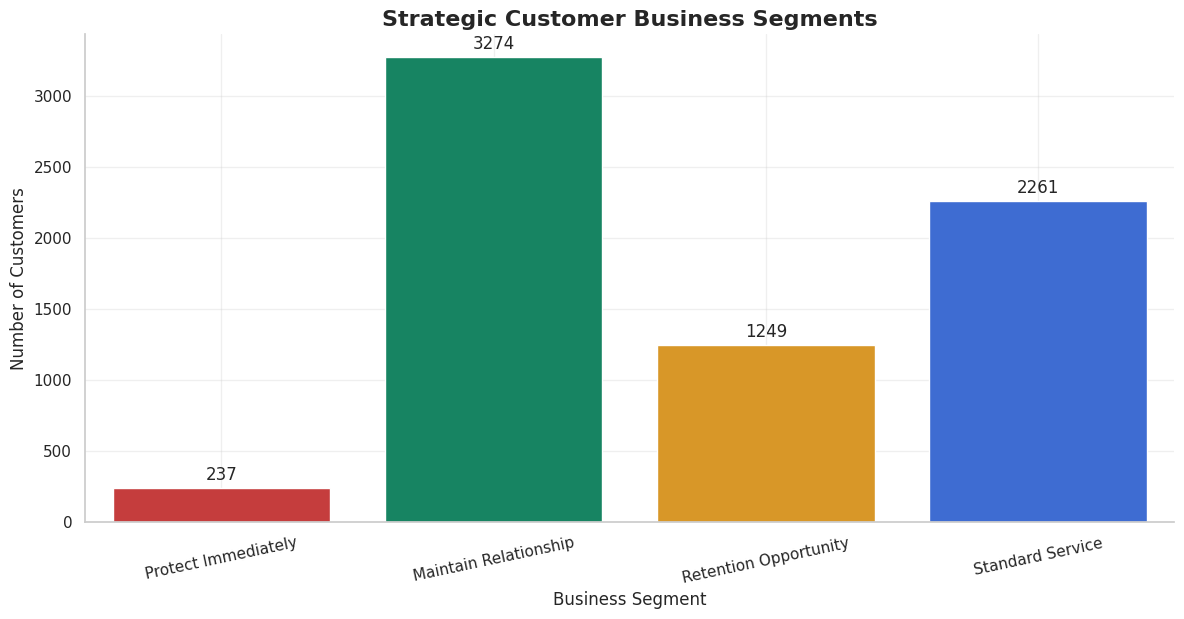

In [130]:
# Business Segment Distribution

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_predictions,
    x="BusinessSegment",
    order=segment_order,
    hue="BusinessSegment",
    palette={
        "Protect Immediately": DANGER,
        "Maintain Relationship": SECONDARY,
        "Retention Opportunity": WARNING,
        "Standard Service": PRIMARY
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

style_chart(
    "Strategic Customer Business Segments",
    "Business Segment",
    "Number of Customers"
)

plt.xticks(rotation=12)
plt.show()

## Customer Value and Churn Risk Matrix

The value-risk matrix compares customer business value with predicted churn probability.

This visualization identifies the customers who combine strong financial importance with elevated churn risk and therefore represent the highest-priority retention opportunities.

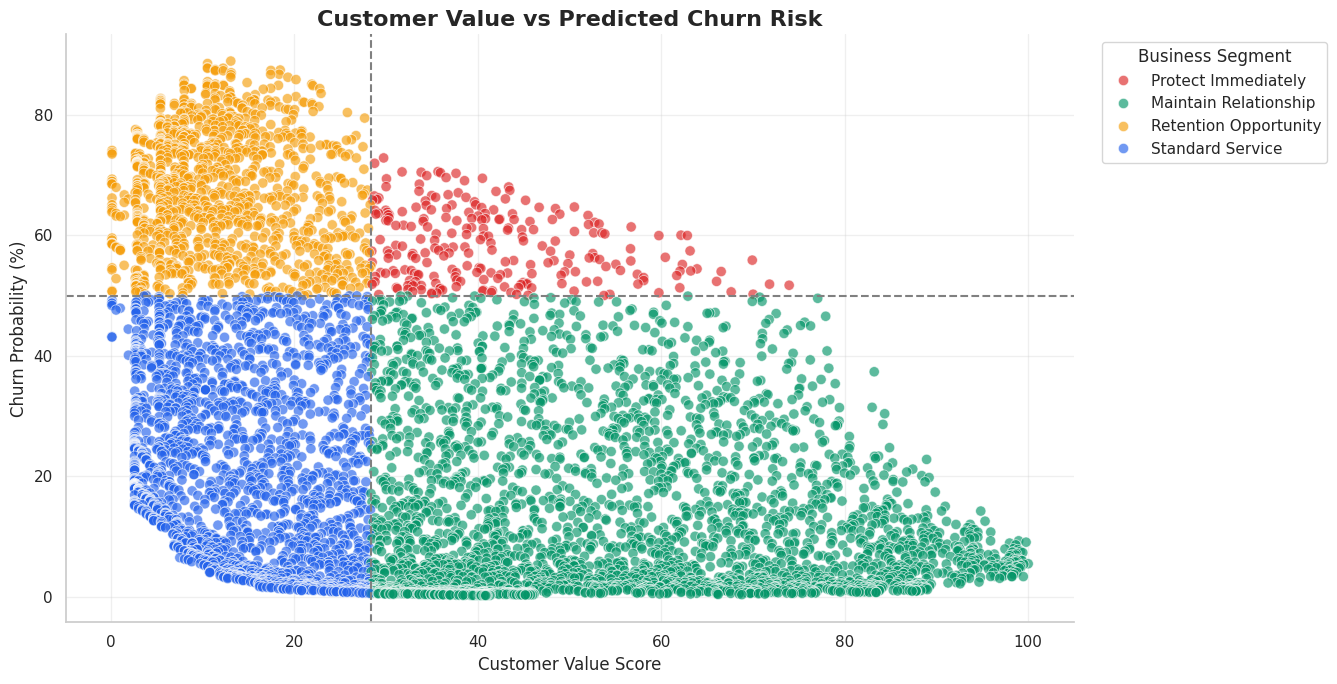

In [133]:
# Customer Value vs Churn Risk

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_predictions,
    x="CustomerValueScore",
    y="ChurnProbabilityPercent",
    hue="BusinessSegment",
    hue_order=segment_order,
    palette={
        "Protect Immediately": DANGER,
        "Maintain Relationship": SECONDARY,
        "Retention Opportunity": WARNING,
        "Standard Service": PRIMARY
    },
    alpha=0.65,
    s=55
)

plt.axhline(
    y=50,
    linestyle="--",
    linewidth=1.5,
    color="gray"
)

plt.axvline(
    x=df_predictions["CustomerValueScore"].median(),
    linestyle="--",
    linewidth=1.5,
    color="gray"
)

style_chart(
    "Customer Value vs Predicted Churn Risk",
    "Customer Value Score",
    "Churn Probability (%)"
)

plt.legend(
    title="Business Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

## High-Value Customers at Risk

High-value customers with elevated churn probabilities represent the most financially significant retention opportunities.

This group should receive immediate attention because the loss of these customers may produce a substantial impact on recurring revenue and customer lifetime value.

In [134]:
# High-Value Customers at Risk

high_value_risk_customers = (
    df_predictions[
        (
            df_predictions["CustomerValueGroup"]
            == "High Value"
        )
        &
        (
            df_predictions["RiskCategory"]
            .isin(["High", "Critical"])
        )
    ]
    .sort_values(
        by=[
            "ChurnProbability",
            "CustomerValueScore"
        ],
        ascending=[
            False,
            False
        ]
    )
)

print(
    "High-value customers at elevated risk:",
    f"{len(high_value_risk_customers):,}"
)

columns_to_show = [
    "CustomerRiskRank",
    "ChurnProbabilityPercent",
    "RiskCategory",
    "RetentionPriority",
    "CustomerValueScore",
    "CustomerLifetimeValue",
    "BusinessSegment"
]

available_columns = [
    column
    for column in columns_to_show
    if column in high_value_risk_customers.columns
]

display(
    high_value_risk_customers[
        available_columns
    ].head(20)
)

High-value customers at elevated risk: 237


,CustomerRiskRank,ChurnProbabilityPercent,RiskCategory,RetentionPriority,CustomerValueScore,CustomerLifetimeValue,BusinessSegment
429,430,72.8800,High,High Priority,29.7500,1971.0000,Protect Immediately
459,460,71.9900,High,High Priority,28.7700,2127.4000,Protect Immediately
517,518,70.6100,High,High Priority,35.6800,2402.3500,Protect Immediately
518,519,70.5600,High,High Priority,31.7600,2433.6000,Protect Immediately
520,521,70.5100,High,High Priority,33.8400,2191.3500,Protect Immediately
523,524,70.4200,High,High Priority,35.9400,2447.2000,Protect Immediately
529,530,70.3200,High,High Priority,37.6400,2856.5000,Protect Immediately
542,543,69.9400,High,High Priority,34.4500,2739.0500,Protect Immediately
558,559,69.6200,High,High Priority,36.5600,2502.0000,Protect Immediately
564,565,69.5000,High,High Priority,40.5200,2972.2000,Protect Immediately


# Dashboard Performance Summary

In [135]:
# Executive Dashboard Report

executive_dashboard_report = pd.DataFrame({
    "Business Area": [
        "Customer Base",
        "Predicted Attrition",
        "Risk Management",
        "Urgent Intervention",
        "Financial Protection"
    ],
    "Metric": [
        "Total Customers",
        "Predicted Churn Rate",
        "High/Critical Risk Customers",
        "Immediate Action Customers",
        "High-Value Customers at Risk"
    ],
    "Result": [
        f"{total_customers:,}",
        f"{predicted_churn_rate:.2f}%",
        f"{high_critical_risk_customers:,}",
        f"{immediate_action_customers:,}",
        f"{high_value_at_risk:,}"
    ],
    "Business Meaning": [
        "Total population covered by the predictive system",
        "Estimated share of customers likely to churn",
        "Customers requiring elevated monitoring",
        "Customers requiring urgent retention action",
        "Financially important customers at elevated risk"
    ]
})

display(executive_dashboard_report)

,Business Area,Metric,Result,Business Meaning
0,Customer Base,Total Customers,"7,021",Total population covered by the predictive system
1,Predicted Attrition,Predicted Churn Rate,21.17%,Estimated share of customers likely to churn
2,Risk Management,High/Critical Risk Customers,"1,486",Customers requiring elevated monitoring
3,Urgent Intervention,Immediate Action Customers,131,Customers requiring urgent retention action
4,Financial Protection,High-Value Customers at Risk,237,Financially important customers at elevated risk


## Business Interpretation

The executive dashboard provides a consolidated view of customer retention performance, predicted churn risk, customer value, and required business action.

The predicted churn rate establishes the overall size of the retention challenge, while the risk and priority distributions identify how many customers require monitoring or immediate intervention.

The business-segment analysis adds financial context by distinguishing customers according to both value and risk. Customers classified as **Protect Immediately** should receive the highest level of retention attention because they combine elevated churn probability with strong business value.

This dashboard enables management to move from broad customer-retention strategies toward targeted, evidence-based intervention.

## Business Recommendations

Based on the executive dashboard, the organization should:

- Prioritize customers classified as **Protect Immediately**.
- Assign immediate-action customers to dedicated retention workflows.
- Protect high-value customers through personalized loyalty incentives.
- Monitor high and critical-risk groups regularly.
- Use lower-cost digital campaigns for retention-opportunity customers.
- Maintain engagement with valuable low-risk customers through loyalty programs.
- Track risk and segment movement over time to measure retention-program effectiveness.

Retention resources should be allocated according to both predicted churn risk and expected customer value.

## Section Summary

The Executive Business Dashboard consolidated customer predictions, risk categories, retention priorities, customer value, and strategic business segments into a management-ready analytical view.

The dashboard identified:

- The overall predicted churn rate
- High and critical-risk customers
- Customers requiring immediate action
- High-value customers at risk
- Strategic customer business segments
- Priority areas for customer-retention investment

These results provide a clear decision-support framework for customer success, marketing, and executive management teams.

The next section will create personalized customer retention recommendations based on each customer's risk, value, service usage, contract profile, and business segment.

# Section 8 — **Customer Retention Recommendations**


Predictive analytics becomes most valuable when model outputs are translated into clear and practical business actions.

This section generates personalized customer retention recommendations based on customer risk, business value, contract type, service adoption, support usage, and strategic customer segment.

The recommendation framework is designed to answer the following question:

**What action should the organization take for each customer based on their predicted churn risk and business importance?**

The resulting recommendations will support customer-success teams, marketing campaigns, account management, and executive retention planning.

## Objectives

This section performs the following tasks:

- Create customer-specific retention recommendations.
- Assign recommended business actions.
- Identify suitable intervention channels.
- Recommend retention offers.
- Summarize recommendations by customer segment.
- Prepare a deployment-ready recommendation dataset.

In [137]:
required_recommendation_columns = [
    "RiskCategory",
    "RetentionPriority",
    "BusinessSegment",
    "Contract",
    "ServiceCount",
    "SupportUsageScore",
    "CustomerValueScore",
    "ChurnProbabilityPercent"
]

missing_recommendation_columns = [
    column
    for column in required_recommendation_columns
    if column not in df_predictions.columns
]

if missing_recommendation_columns:
    print("Missing recommendation columns:")
    for column in missing_recommendation_columns:
        print(f"- {column}")
else:
    print("All recommendation requirements are available.")

All recommendation requirements are available.


In [138]:
# ============================================================
# Recommended Business Action
# ============================================================

def assign_recommended_action(row):

    if row["BusinessSegment"] == "Protect Immediately":
        return (
            "Immediate personalized retention outreach"
        )

    if row["BusinessSegment"] == "Maintain Relationship":
        return (
            "Maintain loyalty and strengthen engagement"
        )

    if row["BusinessSegment"] == "Retention Opportunity":
        return (
            "Provide cost-effective retention offer"
        )

    return "Continue standard customer management"


df_predictions["RecommendedAction"] = (
    df_predictions.apply(
        assign_recommended_action,
        axis=1
    )
)

print("Recommended business actions created successfully.")

Recommended business actions created successfully.


In [139]:
# Recommended Retention Offer

def assign_retention_offer(row):

    if (
        row["RiskCategory"] == "Critical"
        and row["Contract"] == "Month-to-month"
    ):
        return (
            "Annual contract discount and loyalty credit"
        )

    if (
        row["SupportUsageScore"] <= 1
        and row["RiskCategory"] in ["High", "Critical"]
    ):
        return (
            "Complimentary technical support package"
        )

    if (
        row["ServiceCount"] <= 2
        and row["RiskCategory"] in ["High", "Critical"]
    ):
        return (
            "Discounted service bundle"
        )

    if row["BusinessSegment"] == "Maintain Relationship":
        return (
            "Loyalty reward or premium benefit"
        )

    if row["RiskCategory"] == "Moderate":
        return (
            "Targeted promotional offer"
        )

    return "No immediate financial incentive required"


df_predictions["RecommendedOffer"] = (
    df_predictions.apply(
        assign_retention_offer,
        axis=1
    )
)

print("Recommended retention offers created successfully.")

Recommended retention offers created successfully.


In [140]:
# Recommended Communication Channel

def assign_contact_channel(row):

    if row["RetentionPriority"] == "Immediate Action":
        return "Retention specialist phone call"

    if row["RetentionPriority"] == "High Priority":
        return "Personalized email and phone follow-up"

    if row["RetentionPriority"] == "Monitor":
        return "Automated email or in-app message"

    return "Standard marketing communication"


df_predictions["RecommendedChannel"] = (
    df_predictions.apply(
        assign_contact_channel,
        axis=1
    )
)

print("Recommended communication channels created successfully.")

Recommended communication channels created successfully.


In [143]:
# Recommendation Reason

def assign_recommendation_reason(row):

    reasons = []

    if row["RiskCategory"] in ["High", "Critical"]:
        reasons.append("elevated predicted churn risk")

    if row["CustomerValueGroup"] == "High Value":
        reasons.append("high customer value")

    if row["Contract"] == "Month-to-month":
        reasons.append("flexible month-to-month contract")

    if row["ServiceCount"] <= 2:
        reasons.append("low service adoption")

    if row["SupportUsageScore"] <= 1:
        reasons.append("limited support-service usage")

    if not reasons:
        return "stable customer profile"

    return ", ".join(reasons)


df_predictions["RecommendationReason"] = (
    df_predictions.apply(
        assign_recommendation_reason,
        axis=1
    )
)

print("Recommendation reasons created successfully.")

Recommendation reasons created successfully.


In [144]:
# Recommendation Priority Score

df_predictions["RecommendationPriorityScore"] = (
    (
        df_predictions["ChurnProbability"] * 0.60
        +
        (
            df_predictions["CustomerValueScore"] / 100
        ) * 0.40
    )
    * 100
).round(2)

print("Recommendation priority scores created successfully.")

Recommendation priority scores created successfully.


In [145]:
# Recommendation Results Preview

recommendation_columns = [
    "CustomerRiskRank",
    "ChurnProbabilityPercent",
    "RiskCategory",
    "CustomerValueScore",
    "BusinessSegment",
    "RecommendedAction",
    "RecommendedOffer",
    "RecommendedChannel",
    "RecommendationReason",
    "RecommendationPriorityScore"
]

available_recommendation_columns = [
    column
    for column in recommendation_columns
    if column in df_predictions.columns
]

display(
    df_predictions[
        available_recommendation_columns
    ].head(20)
)

,CustomerRiskRank,ChurnProbabilityPercent,RiskCategory,CustomerValueScore,BusinessSegment,RecommendedAction,RecommendedOffer,RecommendedChannel,RecommendationReason,RecommendationPriorityScore
0,1,88.9700,Critical,13.0900,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",58.6200
1,2,88.5600,Critical,10.5600,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",57.3600
2,3,87.8900,Critical,10.5500,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",56.9500
3,4,87.7800,Critical,10.5500,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",56.8900
4,5,87.7800,Critical,12.2600,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",57.5700
5,6,87.5500,Critical,11.4000,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",57.0900
6,7,87.5000,Critical,11.4000,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",57.0600
7,8,87.4800,Critical,18.4800,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",59.8800
8,9,87.4100,Critical,17.4600,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",59.4300
9,10,87.3600,Critical,11.4000,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-...",56.9800


In [146]:
# Retention Recommendation Ranking

df_recommendations = (
    df_predictions
    .sort_values(
        by="RecommendationPriorityScore",
        ascending=False
    )
    .reset_index(drop=True)
)

df_recommendations["RecommendationRank"] = (
    df_recommendations.index + 1
)

display(
    df_recommendations[
        [
            "RecommendationRank",
            "RecommendationPriorityScore",
            "ChurnProbabilityPercent",
            "CustomerValueScore",
            "BusinessSegment",
            "RecommendedAction"
        ]
    ].head(20)
)

,RecommendationRank,RecommendationPriorityScore,ChurnProbabilityPercent,CustomerValueScore,BusinessSegment,RecommendedAction
0,1,61.5100,55.9000,69.9300,Protect Immediately,Immediate personalized retention outreach
1,2,61.1400,59.9900,62.8500,Protect Immediately,Immediate personalized retention outreach
2,3,60.9000,60.0500,62.1600,Protect Immediately,Immediate personalized retention outreach
3,4,60.6200,51.7300,73.9500,Protect Immediately,Immediate personalized retention outreach
4,5,60.5600,49.5600,77.0600,Maintain Relationship,Maintain loyalty and strengthen engagement
5,6,59.8900,59.9800,59.7500,Protect Immediately,Immediate personalized retention outreach
6,7,59.8800,87.4800,18.4800,Retention Opportunity,Provide cost-effective retention offer
7,8,59.8700,51.9100,71.8100,Protect Immediately,Immediate personalized retention outreach
8,9,59.8500,85.1300,21.9200,Retention Opportunity,Provide cost-effective retention offer
9,10,59.7500,84.8900,22.0400,Retention Opportunity,Provide cost-effective retention offer


In [147]:
# Recommendation Action Summary

action_summary = (
    df_recommendations["RecommendedAction"]
    .value_counts()
    .to_frame("Customers")
)

action_summary["Percentage (%)"] = (
    action_summary["Customers"]
    .div(len(df_recommendations))
    .mul(100)
    .round(2)
)

display(action_summary)

,Customers,Percentage (%)
RecommendedAction,,
Maintain loyalty and strengthen engagement,3274,46.6300
Continue standard customer management,2261,32.2000
Provide cost-effective retention offer,1249,17.7900
Immediate personalized retention outreach,237,3.3800


In [148]:
# Retention Offer Summary

offer_summary = (
    df_recommendations["RecommendedOffer"]
    .value_counts()
    .to_frame("Customers")
)

offer_summary["Percentage (%)"] = (
    offer_summary["Customers"]
    .div(len(df_recommendations))
    .mul(100)
    .round(2)
)

display(offer_summary)

,Customers,Percentage (%)
RecommendedOffer,,
Loyalty reward or premium benefit,3274,46.6300
No immediate financial incentive required,1589,22.6300
Complimentary technical support package,968,13.7900
Targeted promotional offer,861,12.2600
Annual contract discount and loyalty credit,328,4.6700
Discounted service bundle,1,0.0100


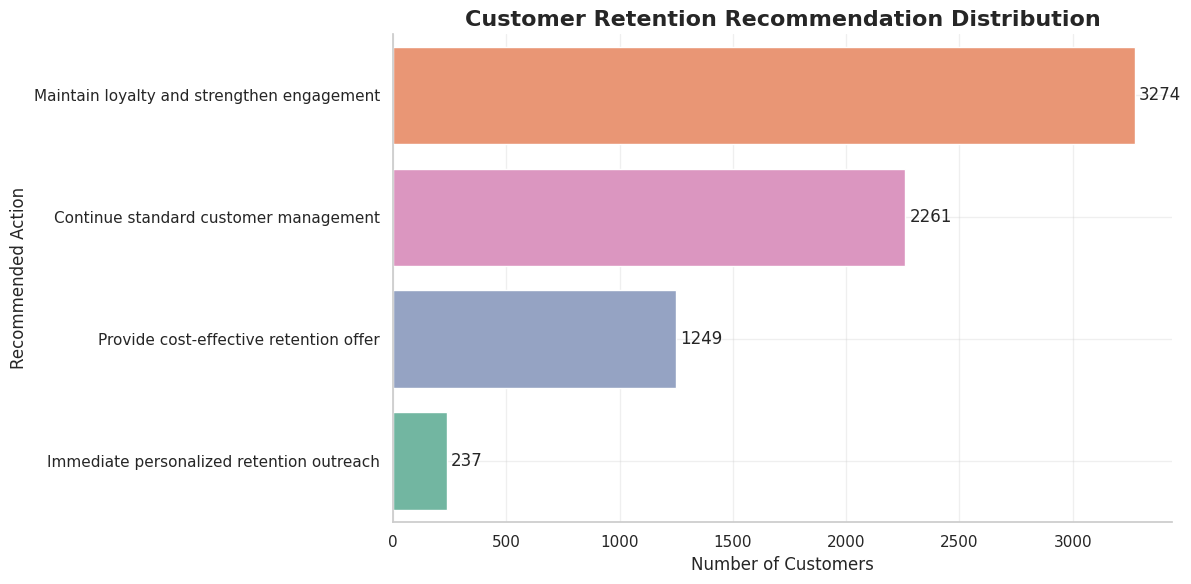

In [149]:
# Recommended Action Distribution

plt.figure(figsize=(12, 6))

action_order = (
    df_recommendations["RecommendedAction"]
    .value_counts()
    .index
)

ax = sns.countplot(
    data=df_recommendations,
    y="RecommendedAction",
    order=action_order,
    hue="RecommendedAction",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

style_chart(
    "Customer Retention Recommendation Distribution",
    "Number of Customers",
    "Recommended Action"
)

plt.show()

In [150]:
# Top Retention Recommendations

top_priority_recommendations = (
    df_recommendations.head(50)
)

top_columns = [
    "RecommendationRank",
    "RecommendationPriorityScore",
    "ChurnProbabilityPercent",
    "RiskCategory",
    "CustomerValueScore",
    "BusinessSegment",
    "RecommendedAction",
    "RecommendedOffer",
    "RecommendedChannel",
    "RecommendationReason"
]

display(
    top_priority_recommendations[
        top_columns
    ]
)

,RecommendationRank,RecommendationPriorityScore,ChurnProbabilityPercent,RiskCategory,CustomerValueScore,BusinessSegment,RecommendedAction,RecommendedOffer,RecommendedChannel,RecommendationReason
0,1,61.5100,55.9000,High,69.9300,Protect Immediately,Immediate personalized retention outreach,No immediate financial incentive required,Automated email or in-app message,"elevated predicted churn risk, high customer v..."
1,2,61.1400,59.9900,High,62.8500,Protect Immediately,Immediate personalized retention outreach,No immediate financial incentive required,Automated email or in-app message,"elevated predicted churn risk, high customer v..."
2,3,60.9000,60.0500,High,62.1600,Protect Immediately,Immediate personalized retention outreach,Complimentary technical support package,Personalized email and phone follow-up,"elevated predicted churn risk, high customer v..."
3,4,60.6200,51.7300,High,73.9500,Protect Immediately,Immediate personalized retention outreach,No immediate financial incentive required,Automated email or in-app message,"elevated predicted churn risk, high customer v..."
4,5,60.5600,49.5600,Moderate,77.0600,Maintain Relationship,Maintain loyalty and strengthen engagement,Loyalty reward or premium benefit,Automated email or in-app message,"high customer value, flexible month-to-month c..."
5,6,59.8900,59.9800,High,59.7500,Protect Immediately,Immediate personalized retention outreach,Complimentary technical support package,Automated email or in-app message,"elevated predicted churn risk, high customer v..."
6,7,59.8800,87.4800,Critical,18.4800,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-..."
7,8,59.8700,51.9100,High,71.8100,Protect Immediately,Immediate personalized retention outreach,No immediate financial incentive required,Automated email or in-app message,"elevated predicted churn risk, high customer v..."
8,9,59.8500,85.1300,Critical,21.9200,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-..."
9,10,59.7500,84.8900,Critical,22.0400,Retention Opportunity,Provide cost-effective retention offer,Annual contract discount and loyalty credit,Retention specialist phone call,"elevated predicted churn risk, flexible month-..."



## Business Interpretation

The recommendation engine converts churn predictions into clear customer-retention actions.

Customers with high churn probability and strong customer value receive the highest recommendation-priority scores. These customers should be contacted first because they represent both elevated attrition risk and significant financial importance.

The recommendations also consider contract flexibility, service adoption, and support usage. This allows the organization to move beyond generic discounts and provide interventions that address each customer’s specific risk profile.

## Recommendations

The organization should operationalize the recommendation framework as follows:

- Assign top-ranked customers to retention specialists.
- Offer annual-contract incentives to high-risk month-to-month customers.
- Provide support-service trials to customers with limited support adoption.
- Promote relevant service bundles to customers with low service engagement.
- Reward valuable low-risk customers through loyalty programs.
- Use lower-cost digital channels for moderate-risk and lower-value customers.
- Track offer acceptance, customer response, and post-intervention churn outcomes.

The recommendation system should be continuously evaluated to determine which retention actions produce the strongest business results.

## Section Summary

This section created a personalized customer retention recommendation framework.

Each customer was assigned:

- A recommended business action
- A recommended retention offer
- A recommended communication channel
- A recommendation reason
- A recommendation-priority score
- A final recommendation rank

The resulting recommendation dataset provides an actionable framework for customer-success teams, marketing departments, and executive decision-makers.

The next section will export the prediction, risk-ranking, segmentation, dashboard, and recommendation outputs for reporting and Streamlit deployment.

# Section 9 — **Export Prediction Results**


The final step of the business intelligence workflow is to export all prediction outputs, customer risk rankings, business segments, executive dashboards, and retention recommendations.

Exporting these datasets allows the prediction results to be used in reporting systems, business dashboards, and deployment within the AI-Powered Customer Retention Intelligence Platform.

The exported files also provide a reusable foundation for future analytics, customer monitoring, and executive decision-making.

These artifacts will be consumed directly by the Streamlit web application developed in the final notebook.

## Objectives

This section performs the following tasks:

- Export the prediction dataset.
- Export customer risk rankings.
- Export retention recommendations.
- Export executive dashboard summaries.
- Export business segment summaries.
- Verify exported files.
- Prepare deployment-ready datasets.

In [152]:
# Create Export Directory

EXPORT_PATH = os.path.join(
    PROJECT_PATH,
    "exports"
)

os.makedirs(
    EXPORT_PATH,
    exist_ok=True
)

print("Export directory verified successfully.")

Export directory verified successfully.


# Define Export Files

In [154]:
# Export File Paths

PREDICTIONS_FILE = os.path.join(
    EXPORT_PATH,
    "customer_predictions.csv"
)

RISK_FILE = os.path.join(
    EXPORT_PATH,
    "customer_risk_ranking.csv"
)

RECOMMENDATION_FILE = os.path.join(
    EXPORT_PATH,
    "customer_retention_recommendations.csv"
)

KPI_FILE = os.path.join(
    EXPORT_PATH,
    "executive_dashboard_kpis.csv"
)

SEGMENT_FILE = os.path.join(
    EXPORT_PATH,
    "business_segments.csv"
)

print("Export paths created successfully.")

Export paths created successfully.


# Export Prediction Dataset

In [156]:
# Export Prediction Dataset

df_predictions.to_csv(
    PREDICTIONS_FILE,
    index=False
)

print("Prediction dataset exported successfully.")

Prediction dataset exported successfully.


# Export Risk Ranking

In [159]:
# Export Risk Ranking

risk_columns = [
    column
    for column in [
        "CustomerRiskRank",
        "ChurnProbability",
        "ChurnProbabilityPercent",
        "RiskCategory",
        "RetentionPriority"
    ]
    if column in df_predictions.columns
]

df_predictions[risk_columns].to_csv(
    RISK_FILE,
    index=False
)

print("Customer risk ranking exported successfully.")

Customer risk ranking exported successfully.


# Export Recommendations

In [164]:
# Export Recommendations

df_recommendations.to_csv(
    RECOMMENDATION_FILE,
    index=False
)

print("Retention recommendations exported successfully.")

Retention recommendations exported successfully.


In [165]:
# Export Dashboard KPIs

executive_kpis.to_csv(
    KPI_FILE,
    index=False
)

print("Executive KPI report exported successfully.")

Executive KPI report exported successfully.


In [167]:
# Export Business Segments

segment_dashboard.to_csv(
    SEGMENT_FILE,
    index=True
)

print("Business segment report exported successfully.")

Business segment report exported successfully.


In [169]:
# Verify Exported Files

export_files = {

    "Predictions": PREDICTIONS_FILE,

    "Risk Ranking": RISK_FILE,

    "Recommendations": RECOMMENDATION_FILE,

    "Executive KPIs": KPI_FILE,

    "Business Segments": SEGMENT_FILE

}

print("="*60)
print("EXPORT VERIFICATION")
print("="*60)

for name, path in export_files.items():

    if os.path.exists(path):

        size = os.path.getsize(path)/1024

        print(
            f"✓ {name:<22}"
            f"{size:8.2f} KB"
        )

    else:

        print(f"✗ {name}")

EXPORT VERIFICATION
✓ Predictions            3422.25 KB
✓ Risk Ranking            329.57 KB
✓ Recommendations        3455.47 KB
✓ Executive KPIs            0.25 KB
✓ Business Segments         0.16 KB


# Export Summary

In [171]:
# Export Summary

export_summary = pd.DataFrame({

    "Dataset":[

        "Prediction Results",

        "Risk Ranking",

        "Retention Recommendations",

        "Executive KPIs",

        "Business Segments"

    ],

    "Status":[

        os.path.exists(PREDICTIONS_FILE),

        os.path.exists(RISK_FILE),

        os.path.exists(RECOMMENDATION_FILE),

        os.path.exists(KPI_FILE),

        os.path.exists(SEGMENT_FILE)

    ]

})

display(export_summary)

,Dataset,Status
0,Prediction Results,True
1,Risk Ranking,True
2,Retention Recommendations,True
3,Executive KPIs,True
4,Business Segments,True


## Business Interpretation

The exported datasets provide a complete customer-retention intelligence package.

The prediction results, customer rankings, business segments, and recommendations can now be integrated into reporting systems, executive dashboards, and operational customer-retention workflows.

These outputs allow organizations to transition from predictive analytics to practical business action.

## Recommendations

Organizations should regularly regenerate these exported reports as new customer data becomes available.

Recommended practices include:

- Refresh churn predictions weekly or monthly.
- Monitor changes in customer risk rankings.
- Evaluate retention campaign effectiveness.
- Measure recommendation acceptance rates.
- Retrain the predictive model periodically using updated customer data.

Maintaining an up-to-date prediction pipeline ensures continued model accuracy and supports proactive customer-retention management.

# Notebook Summary

Notebook 6 successfully transformed machine learning predictions into actionable business intelligence.

The notebook completed the following tasks:

- Loaded the production model.
- Generated churn probabilities.
- Ranked customer risk.
- Created business segments.
- Explained model predictions.
- Built executive dashboards.
- Generated personalized retention recommendations.
- Exported deployment-ready business datasets.

The exported artifacts are now ready for integration into the AI-Powered Customer Retention Intelligence Platform.